In [55]:
import warnings
warnings.filterwarnings('ignore')

import os
import pickle

import numpy as np
import pandas as pd

from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta

from pandas.tseries.offsets import MonthEnd, MonthBegin
from maricovault.MaricoDB import MaricoSnowflake

from joblib import Parallel, delayed

In [56]:
base_dir = '/data/aman_singh/acuuracy_check'
os.chdir(base_dir)

In [57]:
# variables
run_months_list = [ '2026-01-31','2026-02-28',
                   '2026-03-31', '2026-04-30']
# start_date = '2025-08-31'
# end_date = '2026-06-01'

In [58]:
def get_dbconnection(db_name): 

    KEY_VAULT_NAME = "prod-pwd"
    if db_name == 'PROD':
        db_name = 'prod'
    else:
        db_name = 'dev'

    msf = MaricoSnowflake(KEY_VAULT_NAME)
    msf.get_db_credentials(db_name=db_name)
    msf.connect()
    dbconnection = msf.get_connection()
    
    return dbconnection

In [59]:
dev_conn = get_dbconnection('DEV')
prod_conn = get_dbconnection('PROD')


Credentials retrieved successfully for dev db.

Credentials retrieved successfully for prod db.


### Helper functions

In [60]:
realignment_df = pd.read_sql(
    """select * from trn_mil_asm_psku_realignment""",
    dev_conn
)
realignment_df.columns = realignment_df.columns.str.lower()

realignment_df = realignment_df[
    realignment_df['channel'].isin(['QCOM', 'QCOM B2C', 'ALL'])]


def realign_pskus(data, column):
    realignment_data = realignment_df.copy()
    assert realignment_data['psku old'].dtype == 'int64'
    assert realignment_data['psku new'].dtype == 'int64'
    realignment_data = realignment_data[['psku old', 'psku new']].drop_duplicates()
    realignment_data = realignment_data.set_index('psku old').to_dict()['psku new']

    
    data[column] = data[column].astype(int)

    for old_psku, new_psku in realignment_data.items():
        data.loc[
            data[column] == old_psku, column
        ] = new_psku

    return data

In [61]:
from tqdm import tqdm

def impute_missing_dates(
        df,
        freq='M',
        key=['CHAIN', 'FACILITY_NAME', 'PARENT_MATERIAL_CODE'], 
        date_col='MONTH_DATE',
        max_date='2026-09-30'
    ):

    impute_df = df.copy()
    impute_df[date_col] = pd.to_datetime(impute_df[date_col])
    impute_df['key'] = impute_df[key].astype(str).agg('_'.join, axis=1)
    min_dates_df = impute_df.groupby(
        'key', as_index=False
    )[date_col].min()

    def impute_missing_dates_key(key, min_date, max_date):
        df_imputed = pd.DataFrame(
            pd.date_range(min_date, max_date, freq=freq),
            columns=[date_col]
        )
        df_imputed['key'] = key
        return df_imputed
    
    outputs = Parallel(n_jobs=-1)(
        delayed(impute_missing_dates_key)(row['key'], row[date_col], max_date)
        for idx, row in tqdm(min_dates_df.iterrows())
    )
    df_full = pd.concat(outputs)
    df_full.reset_index(drop=True, inplace=True)

    df_full = df_full.merge(
        impute_df, on=['key', date_col], how='left',
    )

    return df_full

In [62]:
non_rc_to_rc_mapping = {
    718948: 722208,
    718356: 721837,
    718455: 721963,
    718341: 721898,
    718342: 721836,
    719008: 721842,
    729186: 729165,
    718288: 721843,
    722301: 722302
}

rc_to_non_rc_mapping = {value: key for key, value in non_rc_to_rc_mapping.items()}

rc_skus = list(rc_to_non_rc_mapping.keys()) + [729280]
non_rc_skus = list(rc_to_non_rc_mapping.values())

In [63]:
def get_final_psku(x):
    if x['zone'] in ['North', 'East']:
        if (x['rc_psku'] == 1):
            return x['parent_material_code']
        else:
            return non_rc_to_rc_mapping[x['parent_material_code']]
    else:
        if (x['rc_psku'] == 0):
            return x['parent_material_code']
        else:
            return rc_to_non_rc_mapping[x['parent_material_code']]   
        
            
def zepto_saff_golf_fix(df):

    df = df.copy()

    zepto_gold_df = df[
        (df['chain'] == 'Zepto') &
        (df['material_group_code'] == 'SAFF GOLD')
    ]

    rest = df[
        ~((df['chain'] == 'Zepto') &
        (df['material_group_code'] == 'SAFF GOLD'))
    ]

    ########### Offtake City to New City ###########
    city_mappings_df = pd.read_excel(
        r'/data/aman_singh/mt_forecast/City Mappings QCOM.xlsb', 
        'Final'
    )

    city_mappings_df.rename(columns={'City': 'warehouse_city', 'Final City': 'final'}, inplace=True)

    city_mappings_df.columns = city_mappings_df.columns.str.lower()

    assert city_mappings_df.duplicated(subset=['platform_name', 'city']).sum() == 0

    city_mappings_df.rename(columns={'platform_name': 'chain'}, inplace=True)
    #####################################################################


    #### New City to Zone Mappings #######
    # region_mappings = pd.read_excel(
    #     r"C:\Users\aniket.patel\OneDrive - Marico Ltd\Zepto - SAFF GOLD - Region Mappings.xlsx"    
    # )
    # region_mappings.columns = region_mappings.columns.str.lower()
    data_region = {
        "city": [
            "Faridabad", "Ahmedabad", "Jaipur", "Patiala", "Pune",
            "Bangalore", "GURGAON", "Medak", "Chennai", "Lucknow",
            "Hyderabad", "Jhajjar", "Howrah", "Mumbai", "Bhiwandi"
        ],
        "State/Region": [
            "Haryana", "Gujarat", "Rajasthan", "Punjab", "Maharashtra",
            "Karnataka", "Haryana", "Telangana", "Tamil Nadu", "Uttar Pradesh",
            "Telangana", "Haryana", "West Bengal", "Maharashtra", "Maharashtra"
        ],
        "zone": [
            "North", "West", "North", "North", "West",
            "South", "North", "South", "South", "North",
            "South", "North", "East", "West", "West"
        ]
    }

    region_mappings = pd.DataFrame(data_region)
    #######################################


    ### FIX ####
    len_before_merge = len(zepto_gold_df)
    zepto_gold_df = zepto_gold_df.merge(
        city_mappings_df[['chain', 'city', 'final']],
        on=['chain', 'city'],
        how='left'
    )
    assert len_before_merge == len(zepto_gold_df)
    del len_before_merge

    zepto_gold_df = zepto_gold_df[zepto_gold_df['final'].notna()]

    len_before_merge = len(zepto_gold_df)
    zepto_gold_df = zepto_gold_df.merge(
        region_mappings[['city', 'zone']].rename(
            columns={'city': 'final'}
        ),
        how='left', 
        on=['final']
    )
    assert len_before_merge == len(zepto_gold_df)
    del len_before_merge


    zepto_gold_df['rc_psku'] = zepto_gold_df['parent_material_code'].map(
        lambda x: 1 if x in rc_skus else 0
    )

    zepto_gold_df['final_psku'] = zepto_gold_df.apply(lambda x: get_final_psku(x), axis=1)

    zepto_gold_df = zepto_gold_df.groupby(
        ['chain', 'city', 'final_psku', 'material_group_code', 
        'month_date'], as_index=False
    )['vol_in_roum'].sum()
    zepto_gold_df.rename(columns={'final_psku': 'parent_material_code'}, inplace=True)

    df = pd.concat([rest, zepto_gold_df], ignore_index=True)

    return df

### Primary Actuals + Sec Plan Data

In [64]:
plan_actuals_query = """
-- Primary base table
SELECT 
    CASE
        WHEN MCM.chain = 'Kiranakart Technologies' THEN 'Zepto'
        WHEN MCM.chain = 'Grofers' THEN 'Blinkit'
        ELSE MCM.chain
    END AS chain,
    DCM.marico_depot,
    MM.parent_material_code,
    MM.material_group_code,
    MESR.month_date,
    SUM(pri_actuals_vol_rum) AS pri_actuals_vol_rum,
    SUM(pri_apo_plan_vol_rum) AS pri_apo_plan_vol_rum,
    SUM(MESR.sec_apo_plan_vol_rum) AS sec_apo_plan_vol_rum,
    SUM(MESR.sec_actuals_vol_rum) AS sec_actuals_vol_rum
FROM
    dwh_bpm_dist_sku_daily MESR
JOIN 
(
    SELECT
        customer,
        chain_type,
        chain
    FROM
        mst_chain_master
    WHERE
        chain IN ('Grofers', 'Swiggy', 'Zepto', 'Kiranakart Technologies')
) MCM ON MESR.distributor_code = MCM.customer
JOIN
(
    SELECT
        material_code,
        parent_material_code,
        material_group_code,
        uom_reporting,
        vol_per_unit
    FROM 
        mst_material
    WHERE
        company_code='MIL' AND
        latest_record_ind=1
) MM ON MESR.material_code = MM.material_code
LEFT JOIN 
(
    SELECT DISTINCT
        customer,
        marico_depot
    FROM
        dev_db.data_science.trn_soh_dc_master
) DCM on MESR.distributor_code = DCM.customer
WHERE month_date > '2023-12-31'
GROUP BY 1, 2, 3, 4, 5
ORDER BY 1, 2, 4, 3, 5
"""

plan_actuals_df = pd.read_sql(
    plan_actuals_query,
    prod_conn
)

In [65]:
plan_actuals_df.columns = plan_actuals_df.columns.str.lower()
plan_actuals_df['month_date'] = pd.to_datetime(plan_actuals_df['month_date'])

In [66]:
plan_actuals_df.duplicated(subset=['chain', 'marico_depot', 'parent_material_code', 
     'material_group_code', 'month_date']).sum()

0

In [67]:
plan_actuals_df[plan_actuals_df['marico_depot'].isna()]#['sec_actuals_vol_rum'].sum()

,chain,marico_depot,parent_material_code,material_group_code,month_date,pri_actuals_vol_rum,pri_apo_plan_vol_rum,sec_apo_plan_vol_rum,sec_actuals_vol_rum
352806,Blinkit,None,718472,ADV-AHO-R,2024-01-01,0.0,0.108491,0.000,0.0
352807,Blinkit,None,718472,ADV-AHO-R,2024-02-01,0.0,0.163414,0.000,0.0
352808,Blinkit,None,718472,ADV-AHO-R,2024-12-31,0.0,0.000000,2.281,0.0
352809,Blinkit,None,718473,ADV-AHO-R,2024-01-01,0.0,0.187036,0.000,0.0
352810,Blinkit,None,718473,ADV-AHO-R,2024-02-01,0.0,0.281743,0.000,0.0
...,...,...,...,...,...,...,...,...,...
731773,Zepto,None,810179,SW_SGPRF,2024-10-01,0.0,11.425066,0.000,0.0
731774,Zepto,None,810179,SW_SGPRF,2024-11-01,0.0,0.466896,0.000,0.0
731775,Zepto,None,810179,SW_SGPRF,2024-12-01,0.0,0.746376,0.000,0.0
731776,Zepto,None,810179,SW_SGPRF,2025-01-01,0.0,0.319030,0.000,0.0


In [68]:
plan_actuals_df.loc[plan_actuals_df['marico_depot'].isna(), 'marico_depot'] = np.nan

In [69]:
plan_actuals_df['marico_depot'] = plan_actuals_df['marico_depot'].str.lower()

In [70]:
plan_actuals_df.shape

(731778, 9)

In [71]:
plan_actuals_df = realign_pskus(plan_actuals_df.copy(), column='parent_material_code')

In [72]:
plan_actuals_df

,chain,marico_depot,parent_material_code,material_group_code,month_date,pri_actuals_vol_rum,pri_apo_plan_vol_rum,sec_apo_plan_vol_rum,sec_actuals_vol_rum
0,Blinkit,d112,718472,ADV-AHO-R,2024-01-01,0.0,0.053040,0.0,0.0
1,Blinkit,d112,718472,ADV-AHO-R,2024-02-01,0.0,0.149204,0.0,0.0
2,Blinkit,d112,718472,ADV-AHO-R,2024-03-01,0.0,0.108107,0.0,0.0
3,Blinkit,d112,718473,ADV-AHO-R,2024-01-01,0.0,0.137200,0.0,0.0
4,Blinkit,d112,718473,ADV-AHO-R,2024-02-01,0.0,0.385826,0.0,0.0
...,...,...,...,...,...,...,...,...,...
731773,Zepto,NaN,810179,SW_SGPRF,2024-10-01,0.0,11.425066,0.0,0.0
731774,Zepto,NaN,810179,SW_SGPRF,2024-11-01,0.0,0.466896,0.0,0.0
731775,Zepto,NaN,810179,SW_SGPRF,2024-12-01,0.0,0.746376,0.0,0.0
731776,Zepto,NaN,810179,SW_SGPRF,2025-01-01,0.0,0.319030,0.0,0.0


In [73]:
plan_actuals_df['month_date'] = plan_actuals_df['month_date'] + MonthEnd(0)

In [74]:
plan_actuals_df.duplicated(subset=['chain', 'marico_depot', 'parent_material_code', 
     'material_group_code', 'month_date']).sum()

487651

In [75]:
plan_actuals_df = plan_actuals_df.groupby(
    ['chain', 'marico_depot', 'parent_material_code', 
     'material_group_code', 'month_date'], as_index=False, dropna=False
).sum()

In [76]:
plan_actuals_df['parent_material_code'] = plan_actuals_df['parent_material_code'].astype(int)

In [77]:
plan_actuals_df = plan_actuals_df[plan_actuals_df['material_group_code']!='PABABY_SP']

In [78]:
plan_actuals_df = impute_missing_dates(
    plan_actuals_df.copy(),
    key=['chain', 'marico_depot', 'parent_material_code'],
    date_col='month_date'
)

22326it [00:05, 3802.63it/s]


In [79]:
plan_actuals_df.sort_values(by=['key', 'month_date'], inplace=True)

In [80]:
cols = ['chain', 'marico_depot', 'parent_material_code', 'material_group_code']

plan_actuals_df[cols] = plan_actuals_df.groupby('key')[cols].transform(lambda x: x.ffill().bfill())

In [81]:
for col in ['pri_actuals_vol_rum', 'pri_apo_plan_vol_rum', 'sec_apo_plan_vol_rum', 'sec_actuals_vol_rum']:
    plan_actuals_df[col] = plan_actuals_df[col].fillna(0)

In [82]:
plan_actuals_df['parent_material_code'] = plan_actuals_df['parent_material_code'].astype(int)

In [83]:
plan_actuals_df.duplicated(subset=['key', 'month_date']).sum()

0

In [84]:
plan_actuals_df

,month_date,key,chain,marico_depot,parent_material_code,material_group_code,pri_actuals_vol_rum,pri_apo_plan_vol_rum,sec_apo_plan_vol_rum,sec_actuals_vol_rum
0,2024-01-31,Blinkit_d112_718287,Blinkit,d112,718287,PCNO(R),0.0,0.001866,0.0000,0.0
1,2024-02-29,Blinkit_d112_718287,Blinkit,d112,718287,PCNO(R),0.0,0.003372,0.0010,0.0
2,2024-03-31,Blinkit_d112_718287,Blinkit,d112,718287,PCNO(R),0.0,0.002172,0.0000,0.0
3,2024-04-30,Blinkit_d112_718287,Blinkit,d112,718287,PCNO(R),0.0,0.004476,0.0000,0.0
4,2024-05-31,Blinkit_d112_718287,Blinkit,d112,718287,PCNO(R),0.0,0.003584,0.0000,0.0
...,...,...,...,...,...,...,...,...,...,...
514072,2026-05-31,Zepto_nan_811287,Zepto,NaN,811287,PA_RSW_SR,0.0,0.000000,10.5533,0.0
514073,2026-06-30,Zepto_nan_811287,Zepto,NaN,811287,PA_RSW_SR,0.0,0.000000,6.3439,0.0
514074,2026-07-31,Zepto_nan_811287,Zepto,NaN,811287,PA_RSW_SR,0.0,0.000000,0.0000,0.0
514075,2026-08-31,Zepto_nan_811287,Zepto,NaN,811287,PA_RSW_SR,0.0,0.000000,0.0000,0.0


In [85]:
plan_actuals_df[plan_actuals_df['marico_depot'].isna()]

,month_date,key,chain,marico_depot,parent_material_code,material_group_code,pri_actuals_vol_rum,pri_apo_plan_vol_rum,sec_apo_plan_vol_rum,sec_actuals_vol_rum
211573,2024-01-31,Blinkit_nan_718287,Blinkit,NaN,718287,PCNO(R),0.0,0.000409,0.0000,0.0
211574,2024-02-29,Blinkit_nan_718287,Blinkit,NaN,718287,PCNO(R),0.0,0.000410,0.0000,0.0
211575,2024-03-31,Blinkit_nan_718287,Blinkit,NaN,718287,PCNO(R),0.0,0.000000,0.0000,0.0
211576,2024-04-30,Blinkit_nan_718287,Blinkit,NaN,718287,PCNO(R),0.0,0.000000,0.0000,0.0
211577,2024-05-31,Blinkit_nan_718287,Blinkit,NaN,718287,PCNO(R),0.0,0.000000,0.0000,0.0
...,...,...,...,...,...,...,...,...,...,...
514072,2026-05-31,Zepto_nan_811287,Zepto,NaN,811287,PA_RSW_SR,0.0,0.000000,10.5533,0.0
514073,2026-06-30,Zepto_nan_811287,Zepto,NaN,811287,PA_RSW_SR,0.0,0.000000,6.3439,0.0
514074,2026-07-31,Zepto_nan_811287,Zepto,NaN,811287,PA_RSW_SR,0.0,0.000000,0.0000,0.0
514075,2026-08-31,Zepto_nan_811287,Zepto,NaN,811287,PA_RSW_SR,0.0,0.000000,0.0000,0.0


In [86]:
for col in ['pri_actuals_vol_rum', 'pri_apo_plan_vol_rum', 'sec_apo_plan_vol_rum', 'sec_actuals_vol_rum']:
    if plan_actuals_df[col].min() < 0:
        print(col)

pri_actuals_vol_rum
sec_actuals_vol_rum


In [87]:
for col in ['pri_actuals_vol_rum', 'pri_apo_plan_vol_rum', 'sec_apo_plan_vol_rum', 'sec_actuals_vol_rum']:
    plan_actuals_df[col] = plan_actuals_df[col].clip(lower=0)

In [88]:
for col in ['pri_actuals_vol_rum', 'pri_apo_plan_vol_rum', 'sec_apo_plan_vol_rum', 'sec_actuals_vol_rum']:
    if plan_actuals_df[col].min() < 0:
        print(col)

In [89]:
plan_actuals_df

,month_date,key,chain,marico_depot,parent_material_code,material_group_code,pri_actuals_vol_rum,pri_apo_plan_vol_rum,sec_apo_plan_vol_rum,sec_actuals_vol_rum
0,2024-01-31,Blinkit_d112_718287,Blinkit,d112,718287,PCNO(R),0.0,0.001866,0.0000,0.0
1,2024-02-29,Blinkit_d112_718287,Blinkit,d112,718287,PCNO(R),0.0,0.003372,0.0010,0.0
2,2024-03-31,Blinkit_d112_718287,Blinkit,d112,718287,PCNO(R),0.0,0.002172,0.0000,0.0
3,2024-04-30,Blinkit_d112_718287,Blinkit,d112,718287,PCNO(R),0.0,0.004476,0.0000,0.0
4,2024-05-31,Blinkit_d112_718287,Blinkit,d112,718287,PCNO(R),0.0,0.003584,0.0000,0.0
...,...,...,...,...,...,...,...,...,...,...
514072,2026-05-31,Zepto_nan_811287,Zepto,NaN,811287,PA_RSW_SR,0.0,0.000000,10.5533,0.0
514073,2026-06-30,Zepto_nan_811287,Zepto,NaN,811287,PA_RSW_SR,0.0,0.000000,6.3439,0.0
514074,2026-07-31,Zepto_nan_811287,Zepto,NaN,811287,PA_RSW_SR,0.0,0.000000,0.0000,0.0
514075,2026-08-31,Zepto_nan_811287,Zepto,NaN,811287,PA_RSW_SR,0.0,0.000000,0.0000,0.0


In [90]:
plan_actuals_df.sort_values(by=['key', 'month_date'], inplace=True)

In [91]:
plan_actuals_df.duplicated(subset=['key', 'month_date']).sum()

0

In [92]:
plan_actuals_df['Primary P3M'] = plan_actuals_df.groupby(
    ['key'], 
    as_index = False, group_keys = False
)['pri_actuals_vol_rum'].shift(1).rolling(window=3, min_periods=1).mean()

In [93]:
plan_actuals_df.sample(1)

,month_date,key,chain,marico_depot,parent_material_code,material_group_code,pri_actuals_vol_rum,pri_apo_plan_vol_rum,sec_apo_plan_vol_rum,sec_actuals_vol_rum,Primary P3M
360546,2024-06-30,Swiggy_d674_718450,Swiggy,d674,718450,PADV-HOT,0.0,0.0,0.0,0.0,0.0


In [94]:
plan_actuals_df

,month_date,key,chain,marico_depot,parent_material_code,material_group_code,pri_actuals_vol_rum,pri_apo_plan_vol_rum,sec_apo_plan_vol_rum,sec_actuals_vol_rum,Primary P3M
0,2024-01-31,Blinkit_d112_718287,Blinkit,d112,718287,PCNO(R),0.0,0.001866,0.0000,0.0,NaN
1,2024-02-29,Blinkit_d112_718287,Blinkit,d112,718287,PCNO(R),0.0,0.003372,0.0010,0.0,0.0
2,2024-03-31,Blinkit_d112_718287,Blinkit,d112,718287,PCNO(R),0.0,0.002172,0.0000,0.0,0.0
3,2024-04-30,Blinkit_d112_718287,Blinkit,d112,718287,PCNO(R),0.0,0.004476,0.0000,0.0,0.0
4,2024-05-31,Blinkit_d112_718287,Blinkit,d112,718287,PCNO(R),0.0,0.003584,0.0000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
514072,2026-05-31,Zepto_nan_811287,Zepto,NaN,811287,PA_RSW_SR,0.0,0.000000,10.5533,0.0,0.0
514073,2026-06-30,Zepto_nan_811287,Zepto,NaN,811287,PA_RSW_SR,0.0,0.000000,6.3439,0.0,0.0
514074,2026-07-31,Zepto_nan_811287,Zepto,NaN,811287,PA_RSW_SR,0.0,0.000000,0.0000,0.0,0.0
514075,2026-08-31,Zepto_nan_811287,Zepto,NaN,811287,PA_RSW_SR,0.0,0.000000,0.0000,0.0,0.0


In [95]:
# plan_actuals_df.groupby(
#     ['chain', 'parent_material_code', 
#      'material_group_code', 'month_date'], as_index=False, dropna=False
# ).sum().to_csv('plan_actuals_aggregated.csv', index=False)

### Offtakes

In [96]:
offtakes_monthly_query = """
SELECT
    OTM.platform_name AS chain,
    OTM.city,
    MM.parent_material_code,
    MM.material_group_code,
    OTM.month_date,
    SUM(CASE
        WHEN MM.uom_reporting IN ('KL', 'TO') THEN ROUND(OTM.vol_in_lit / POW(10, 3), 4)
        ELSE OTM.vol_in_lit
    END) AS vol_in_roum
FROM 
    dwh_ecommplatform_offtake OTM
JOIN
(
    SELECT
        material_code,
        parent_material_code,
        material_group_code,
        uom_reporting,
        vol_per_unit
    FROM 
        mst_material
    WHERE
        company_code='MIL' AND
        latest_record_ind=1
) MM ON OTM.material_code = MM.material_code
WHERE
    OTM.platform_name IN ('Blinkit', 'Swiggy', 'Zepto') AND
    OTM.month_date > '2022-12-31' 
GROUP BY 1, 2, 3, 4, 5
ORDER BY 1, 2, 3, 5, 4
""" 

offtakes_monthly_df = pd.read_sql(
    offtakes_monthly_query,
    prod_conn
)

In [97]:
offtakes_monthly_df.columns = offtakes_monthly_df.columns.str.lower()
offtakes_monthly_df['month_date'] = pd.to_datetime(offtakes_monthly_df['month_date'])
offtakes_monthly_df.head()

,chain,city,parent_material_code,material_group_code,month_date,vol_in_roum
0,Blinkit,Abohar,718398,SAFF ACTV,2026-05-31,0.0130
1,Blinkit,Abohar,718434,PADVJAS-R,2026-05-31,0.3000
2,Blinkit,Abohar,718553,PA-BDYLOT,2026-05-31,0.4000
3,Blinkit,Abohar,718559,SFOATS-FL,2026-05-31,0.0001
4,Blinkit,Abohar,718681,PADV-HRCR,2026-05-31,0.1000


In [98]:
offtakes_monthly_df['month_date'].max()

Timestamp('2026-05-31 00:00:00')

In [99]:
offtakes_monthly_df['parent_material_code'] = offtakes_monthly_df['parent_material_code'].astype(int)

In [100]:
offtakes_monthly_df = zepto_saff_golf_fix(offtakes_monthly_df.copy())

In [101]:
offtakes_monthly_df['run_month'] = offtakes_monthly_df['month_date'] + MonthEnd(0)

In [102]:
zepto_mapping = pd.read_excel('/data/aman_singh/mt_forecast/Q-com Depot-FC-City Mapping v2.0.xlsx', sheet_name = 'Zepto')
zepto_mapping = zepto_mapping[zepto_mapping['Status'] == 'Active']
zepto_mapping = zepto_mapping[['Channel','City', 'Marico Depot']].drop_duplicates()
zepto_mapping.rename(columns = {'Channel':'platform_name', 'City':'city', 'Marico Depot':'depot'}, inplace = True)
zepto_mapping['platform_name'] = zepto_mapping['platform_name'].str.lower()
zepto_mapping['city'] = zepto_mapping['city'].str.lower()

blinkit_mapping = pd.read_excel('/data/aman_singh/mt_forecast/Q-com Depot-FC-City Mapping v2.0.xlsx', sheet_name = 'BlinkIt')
blinkit_mapping = blinkit_mapping[['Channel','City', 'Marico Depot']].drop_duplicates()
blinkit_mapping.rename(columns = {'Channel':'platform_name', 'City':'city', 'Marico Depot':'depot'}, inplace = True)
blinkit_mapping['platform_name'] = blinkit_mapping['platform_name'].str.lower()
blinkit_mapping['city'] = blinkit_mapping['city'].str.lower()

swiggy_mapping = pd.read_excel('/data/aman_singh/mt_forecast/Q-com Depot-FC-City Mapping v2.0.xlsx', sheet_name = 'Swiggy')
swiggy_mapping = swiggy_mapping[['Channel','City', 'Marico Depot']].drop_duplicates()
swiggy_mapping.rename(columns = {'Channel':'platform_name', 'City':'city', 'Marico Depot':'depot'}, inplace = True)
swiggy_mapping['platform_name'] = swiggy_mapping['platform_name'].str.lower()
swiggy_mapping['city'] = swiggy_mapping['city'].str.lower()

depot_city_mapping = pd.concat([zepto_mapping, blinkit_mapping, swiggy_mapping])
depot_city_mapping[depot_city_mapping.duplicated(subset=['platform_name', 'city'], keep = False)]


,platform_name,city,depot


In [103]:
x = offtakes_monthly_df.copy()
#offtake_df = x.copy()

In [104]:
offtakes_monthly_df

,chain,city,parent_material_code,material_group_code,month_date,vol_in_roum,run_month
0,Blinkit,Abohar,718398,SAFF ACTV,2026-05-31,0.0130,2026-05-31
1,Blinkit,Abohar,718434,PADVJAS-R,2026-05-31,0.3000,2026-05-31
2,Blinkit,Abohar,718553,PA-BDYLOT,2026-05-31,0.4000,2026-05-31
3,Blinkit,Abohar,718559,SFOATS-FL,2026-05-31,0.0001,2026-05-31
4,Blinkit,Abohar,718681,PADV-HRCR,2026-05-31,0.1000,2026-05-31
...,...,...,...,...,...,...,...
656082,Zepto,Warangal,729186,SAFF GOLD,2025-06-30,0.0030,2025-06-30
656083,Zepto,Warangal,729186,SAFF GOLD,2025-07-31,0.0030,2025-07-31
656084,Zepto,Warangal,729186,SAFF GOLD,2025-08-31,0.0060,2025-08-31
656085,Zepto,Warangal,729186,SAFF GOLD,2025-10-31,0.0030,2025-10-31


In [105]:
depot_city_mapping.rename(columns = {'platform_name':'chain'}, inplace = True)

In [106]:

offtakes_monthly_df['chain'] = offtakes_monthly_df['chain'].str.lower()
offtakes_monthly_df['city'] = offtakes_monthly_df['city'].str.lower()
len_before_merge = len(offtakes_monthly_df)
offtakes_monthly_df = offtakes_monthly_df.merge(depot_city_mapping, on = ['chain', 'city'], how = 'left')
assert len_before_merge == len(offtakes_monthly_df)
offtakes_monthly_df


,chain,city,parent_material_code,material_group_code,month_date,vol_in_roum,run_month,depot
0,blinkit,abohar,718398,SAFF ACTV,2026-05-31,0.0130,2026-05-31,NaN
1,blinkit,abohar,718434,PADVJAS-R,2026-05-31,0.3000,2026-05-31,NaN
2,blinkit,abohar,718553,PA-BDYLOT,2026-05-31,0.4000,2026-05-31,NaN
3,blinkit,abohar,718559,SFOATS-FL,2026-05-31,0.0001,2026-05-31,NaN
4,blinkit,abohar,718681,PADV-HRCR,2026-05-31,0.1000,2026-05-31,NaN
...,...,...,...,...,...,...,...,...
656082,zepto,warangal,729186,SAFF GOLD,2025-06-30,0.0030,2025-06-30,D530
656083,zepto,warangal,729186,SAFF GOLD,2025-07-31,0.0030,2025-07-31,D530
656084,zepto,warangal,729186,SAFF GOLD,2025-08-31,0.0060,2025-08-31,D530
656085,zepto,warangal,729186,SAFF GOLD,2025-10-31,0.0030,2025-10-31,D530


In [107]:
df1 = offtakes_monthly_df[~offtakes_monthly_df['depot'].isna()]
df2 = offtakes_monthly_df[offtakes_monthly_df['depot'].isna()]

missing_depots = pd.read_csv('/data/aman_singh/mt_forecast/depot_missing_2.csv')
missing_depots.rename(columns = {'Unnamed: 3':'depot', 'platform_name':'chain'}, inplace = True)

df2.drop(columns = ['depot'],inplace = True)
df2 = df2.merge(missing_depots[['chain', 'city', 'depot']], on = ['chain','city'], how = 'left')

df2[df2['depot'].isna()]#.to_csv('missing_depots.csv')#['city'].unique()
df2 = df2.dropna()
offtakes_monthly_df = pd.concat([df1,df2])
offtakes_monthly_df

,chain,city,parent_material_code,material_group_code,month_date,vol_in_roum,run_month,depot
16,blinkit,agra,718312,PCNO(R),2024-08-31,0.003,2024-08-31,D115
17,blinkit,agra,718312,PCNO(R),2024-09-30,0.012,2024-09-30,D115
18,blinkit,agra,718312,PCNO(R),2024-10-31,0.024,2024-10-31,D115
19,blinkit,agra,718312,PCNO(R),2024-11-30,0.031,2024-11-30,D115
20,blinkit,agra,718312,PCNO(R),2024-12-31,0.040,2024-12-31,D115
...,...,...,...,...,...,...,...,...
9998,zepto,valsad,719008,SAFF GOLD,2026-02-28,0.003,2026-02-28,D356
9999,zepto,valsad,719008,SAFF GOLD,2026-03-31,0.009,2026-03-31,D356
10000,zepto,valsad,719008,SAFF GOLD,2026-04-30,0.015,2026-04-30,D356
10001,zepto,valsad,719008,SAFF GOLD,2026-05-31,0.036,2026-05-31,D356


In [108]:
offtakes_monthly_df = offtakes_monthly_df.groupby(['chain', 'depot', 'parent_material_code', 'material_group_code', 'month_date'], as_index=False)[['vol_in_roum']].sum()
offtakes_monthly_df

,chain,depot,parent_material_code,material_group_code,month_date,vol_in_roum
0,blinkit,D112,718288,SAFF GOLD,2024-05-31,0.1450
1,blinkit,D112,718310,PCNO(R),2025-04-30,0.0130
2,blinkit,D112,718310,PCNO(R),2025-05-31,0.0380
3,blinkit,D112,718310,PCNO(R),2025-06-30,0.0930
4,blinkit,D112,718310,PCNO(R),2025-07-31,0.0915
...,...,...,...,...,...,...
171073,zepto,D677,810405,PURSNS_ML,2025-02-28,0.0600
171074,zepto,D677,810406,PURSNS_ML,2025-01-31,0.0300
171075,zepto,D677,810406,PURSNS_ML,2025-02-28,0.0300
171076,zepto,D677,810407,PURSNS_ML,2025-02-28,0.0300


In [109]:
offtakes_monthly_df.duplicated(subset=['chain', 'depot','parent_material_code', 'month_date']).sum()

0

In [110]:
offtakes_monthly_df = realign_pskus(offtakes_monthly_df.copy(), 'parent_material_code')

In [111]:
# offtakes_monthly_df.duplicated(subset=['chain', 'parent_material_code', 'month_date']).sum()

In [112]:
offtakes_monthly_df = offtakes_monthly_df.groupby(
    ['chain', 'depot','parent_material_code', 'material_group_code', 
     'month_date'], as_index=False
)['vol_in_roum'].sum()

In [113]:
offtakes_monthly_df['month_date'].max()

Timestamp('2026-05-31 00:00:00')

#### Add m month forecast

In [114]:
# mmonth_ot_df = pd.read_sql("""
# SELECT * FROM TRN_DF_QCOM_OFFTAKE_CHAIN_DEPOT_PSKU
# WHERE run_month='2026-06-30' AND month_date='2026-05-31'  
# """,
# dev_conn
# )

In [115]:
# offtakes_monthly_df

In [116]:
# mmonth_ot_df

In [117]:
# mmonth_ot_df.columns = mmonth_ot_df.columns.str.lower()
# mmonth_ot_df.rename(
#     columns={
#         'platform_name': 'chain',
#         'brand_code': 'material_group_code',
#         'vol_in_rum': 'vol_in_roum'
#     }, 
#     inplace=True
# )

In [118]:
# mmonth_ot_df['parent_material_code'] = mmonth_ot_df['parent_material_code'].astype(int)

In [119]:
# mmonth_ot_df['month_date'] = pd.to_datetime(mmonth_ot_df['month_date'])
# mmonth_ot_df['run_month'] = pd.to_datetime(mmonth_ot_df['run_month'])

####

In [120]:
# x = offtakes_monthly_df.copy()

In [121]:
# offtakes_monthly_df = pd.concat([offtakes_monthly_df, mmonth_ot_df], ignore_index=True)

In [122]:
offtakes_monthly_df.duplicated(subset=['chain', 'depot','parent_material_code', 'month_date']).sum()

0

In [123]:
offtakes_monthly_df = impute_missing_dates(
    offtakes_monthly_df.copy(),
    key=['chain', 'depot','parent_material_code'],
    date_col='month_date'
)

11258it [00:02, 4832.87it/s]


In [124]:
offtakes_monthly_df.sort_values(by=['key', 'month_date'], inplace=True)

cols = ['chain', 'depot','parent_material_code', 'material_group_code']

offtakes_monthly_df[cols] = offtakes_monthly_df.groupby('key')[cols].transform(lambda x: x.ffill().bfill())

In [125]:
offtakes_monthly_df['run_month'] = offtakes_monthly_df['month_date'] + MonthEnd(0)

In [126]:
offtakes_monthly_df['vol_in_roum'] = offtakes_monthly_df['vol_in_roum'].fillna(0)

In [127]:
offtakes_monthly_df['parent_material_code'] = offtakes_monthly_df['parent_material_code'].astype(int)

In [128]:
(offtakes_monthly_df['key'] == offtakes_monthly_df[['chain', 'depot','parent_material_code']].astype(str).agg('_'.join, axis=1)).all()

True

In [129]:
offtakes_monthly_df.rename(columns={'vol_in_roum': 'offtake_vol_rum'}, inplace=True)

In [130]:
offtakes_monthly_df.groupby(['month_date'])['offtake_vol_rum'].sum()[20:]

month_date
2024-09-30     26332.4787
2024-10-31     33481.2734
2024-11-30     50496.0371
2024-12-31     59153.6373
2025-01-31     63434.0424
2025-02-28     69783.5690
2025-03-31     77069.4825
2025-04-30     70404.5559
2025-05-31     63749.8364
2025-06-30     66717.0806
2025-07-31     73357.6077
2025-08-31     73299.0452
2025-09-30     78360.9210
2025-10-31    100520.0357
2025-11-30    161379.7587
2025-12-31    159464.8876
2026-01-31    149000.6653
2026-02-28    121125.8331
2026-03-31    142572.8285
2026-04-30    134238.5553
2026-05-31    130265.9974
2026-06-30         0.0000
2026-07-31         0.0000
2026-08-31         0.0000
2026-09-30         0.0000
Name: offtake_vol_rum, dtype: float64

In [131]:
# offtakes_monthly_df[offtakes_monthly_df['month_date'] < '2026-02-28'].to_excel('Offtakes Chain PSKU till Jan26.xlsx', index=False)

In [132]:
offtakes_monthly_df


,month_date,key,chain,depot,parent_material_code,material_group_code,offtake_vol_rum,run_month
0,2024-05-31,blinkit_D112_718288,blinkit,D112,718288,SAFF GOLD,0.145,2024-05-31
1,2024-06-30,blinkit_D112_718288,blinkit,D112,718288,SAFF GOLD,0.000,2024-06-30
2,2024-07-31,blinkit_D112_718288,blinkit,D112,718288,SAFF GOLD,0.000,2024-07-31
3,2024-08-31,blinkit_D112_718288,blinkit,D112,718288,SAFF GOLD,0.000,2024-08-31
4,2024-09-30,blinkit_D112_718288,blinkit,D112,718288,SAFF GOLD,0.000,2024-09-30
...,...,...,...,...,...,...,...,...
285916,2026-05-31,zepto_D677_810439,zepto,D677,810439,SAF-MUSLI,0.000,2026-05-31
285917,2026-06-30,zepto_D677_810439,zepto,D677,810439,SAF-MUSLI,0.000,2026-06-30
285918,2026-07-31,zepto_D677_810439,zepto,D677,810439,SAF-MUSLI,0.000,2026-07-31
285919,2026-08-31,zepto_D677_810439,zepto,D677,810439,SAF-MUSLI,0.000,2026-08-31


In [133]:
offtakes_monthly_df['key'] = offtakes_monthly_df['key'].str.lower()
offtakes_monthly_df

,month_date,key,chain,depot,parent_material_code,material_group_code,offtake_vol_rum,run_month
0,2024-05-31,blinkit_d112_718288,blinkit,D112,718288,SAFF GOLD,0.145,2024-05-31
1,2024-06-30,blinkit_d112_718288,blinkit,D112,718288,SAFF GOLD,0.000,2024-06-30
2,2024-07-31,blinkit_d112_718288,blinkit,D112,718288,SAFF GOLD,0.000,2024-07-31
3,2024-08-31,blinkit_d112_718288,blinkit,D112,718288,SAFF GOLD,0.000,2024-08-31
4,2024-09-30,blinkit_d112_718288,blinkit,D112,718288,SAFF GOLD,0.000,2024-09-30
...,...,...,...,...,...,...,...,...
285916,2026-05-31,zepto_d677_810439,zepto,D677,810439,SAF-MUSLI,0.000,2026-05-31
285917,2026-06-30,zepto_d677_810439,zepto,D677,810439,SAF-MUSLI,0.000,2026-06-30
285918,2026-07-31,zepto_d677_810439,zepto,D677,810439,SAF-MUSLI,0.000,2026-07-31
285919,2026-08-31,zepto_d677_810439,zepto,D677,810439,SAF-MUSLI,0.000,2026-08-31


### SOH

In [134]:
soh_query = """
SELECT 
    SOH.final_chains_ho AS chain,
    DCM.marico_depot,
    SOH.parent_sku AS parent_material_code,
    SOH.as_on_date,
    SUM(current_soh) AS current_soh
FROM dev_db.public.dwh_soh_oos SOH
LEFT JOIN 
(
    SELECT DISTINCT
        customer,
        marico_depot
    FROM
        dev_db.data_science.trn_soh_dc_master
) DCM on SOH.distributorcode = DCM.customer
WHERE 
    final_chains_ho IN ('Swiggy', 'Blinkit', 'Zepto') AND
    vol_bpm='Vol'
GROUP BY
    1, 2, 3, 4
ORDER BY
    1, 2, 3, 4
"""

soh_df = pd.read_sql(
    soh_query,
    dev_conn
)

In [135]:
soh_df.columns = soh_df.columns.str.lower()

In [136]:
soh_df.duplicated(subset=['chain', 'marico_depot', 'parent_material_code', 'as_on_date']).sum()

0

In [137]:
soh_df['as_on_date'] = pd.to_datetime(soh_df['as_on_date'])
# soh_df[soh_df['as_on_date'] >= '2026-01-31'].to_csv('soh_recent_qcom.csv', index=False)

In [138]:
soh_df = realign_pskus(soh_df.copy(), 'parent_material_code')

In [139]:
soh_df.duplicated(subset=['chain', 'marico_depot', 'parent_material_code', 'as_on_date']).sum()

76839

In [140]:
soh_df = soh_df.groupby(
    ['chain', 'marico_depot', 'parent_material_code', 'as_on_date'],
    as_index=False
)['current_soh'].sum()

In [141]:
soh_df['as_on_date'].max()

Timestamp('2026-06-03 00:00:00')

In [142]:
soh_df['current_soh'].min()

0.0

In [143]:
soh_df.duplicated(subset=['chain', 'marico_depot', 'parent_material_code', 'as_on_date']).sum()

0

In [144]:
soh_df['marico_depot'] = soh_df['marico_depot'].str.lower()

In [145]:
soh_df['key2'] = soh_df[['chain', 'marico_depot', 'parent_material_code']].astype(str).agg('_'.join, axis=1)

In [146]:
soh_df['as_on_date'] = pd.to_datetime(soh_df['as_on_date'])

In [147]:
soh_df['run_month'] = soh_df['as_on_date'] + MonthEnd(0)

In [148]:
date_wise_soh_vol_sum = soh_df.groupby(['as_on_date'], as_index=False)['current_soh'].sum()

In [149]:
date_wise_soh_vol_sum[date_wise_soh_vol_sum['current_soh'] == 0]

,as_on_date,current_soh
0,2025-01-19,0.0
1,2025-01-20,0.0
19,2025-07-31,0.0
22,2025-08-03,0.0
29,2025-08-12,0.0
34,2025-08-20,0.0
40,2025-08-28,0.0
53,2025-09-15,0.0
56,2025-09-20,0.0
60,2025-09-25,0.0


In [150]:
soh_df[
    soh_df['as_on_date'].isin(
        date_wise_soh_vol_sum[date_wise_soh_vol_sum['current_soh'] == 0]['as_on_date'].unique()
    )
]['current_soh'].sum()

0.0

In [151]:
soh_df = soh_df[
    ~soh_df['as_on_date'].isin(
        date_wise_soh_vol_sum[date_wise_soh_vol_sum['current_soh'] == 0]['as_on_date'].unique()
    )
]

In [152]:
soh_df['current_soh'].sum()

14535062.53978667

In [153]:
soh_df.groupby(['chain'])['as_on_date'].max()

chain
Blinkit   2026-06-03
Swiggy    2026-06-03
Zepto     2026-06-03
Name: as_on_date, dtype: datetime64[ns]

In [154]:
soh_df = soh_df[soh_df['as_on_date'] < '2026-06-01']

### Collate Everything

In [155]:
print(f"SOH", soh_df['chain'].unique())
print("Offtakes:", offtakes_monthly_df['chain'].unique())
print("Plan Actuals:", plan_actuals_df['chain'].unique())

SOH ['Blinkit' 'Swiggy' 'Zepto']
Offtakes: ['blinkit' 'swiggy' 'zepto']
Plan Actuals: ['Blinkit' 'Swiggy' 'Zepto']


In [156]:
plan_actuals_df

,month_date,key,chain,marico_depot,parent_material_code,material_group_code,pri_actuals_vol_rum,pri_apo_plan_vol_rum,sec_apo_plan_vol_rum,sec_actuals_vol_rum,Primary P3M
0,2024-01-31,Blinkit_d112_718287,Blinkit,d112,718287,PCNO(R),0.0,0.001866,0.0000,0.0,NaN
1,2024-02-29,Blinkit_d112_718287,Blinkit,d112,718287,PCNO(R),0.0,0.003372,0.0010,0.0,0.0
2,2024-03-31,Blinkit_d112_718287,Blinkit,d112,718287,PCNO(R),0.0,0.002172,0.0000,0.0,0.0
3,2024-04-30,Blinkit_d112_718287,Blinkit,d112,718287,PCNO(R),0.0,0.004476,0.0000,0.0,0.0
4,2024-05-31,Blinkit_d112_718287,Blinkit,d112,718287,PCNO(R),0.0,0.003584,0.0000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
514072,2026-05-31,Zepto_nan_811287,Zepto,NaN,811287,PA_RSW_SR,0.0,0.000000,10.5533,0.0,0.0
514073,2026-06-30,Zepto_nan_811287,Zepto,NaN,811287,PA_RSW_SR,0.0,0.000000,6.3439,0.0,0.0
514074,2026-07-31,Zepto_nan_811287,Zepto,NaN,811287,PA_RSW_SR,0.0,0.000000,0.0000,0.0,0.0
514075,2026-08-31,Zepto_nan_811287,Zepto,NaN,811287,PA_RSW_SR,0.0,0.000000,0.0000,0.0,0.0


In [157]:
plan_actuals_df.rename(columns={'key': 'key2'}, inplace=True)

In [163]:
final_df = plan_actuals_df[
    ['key2', 'chain', 'marico_depot', 'parent_material_code', 'material_group_code']
].drop_duplicates()

tmp_df = pd.DataFrame()

for rm in run_months_list: 
    mth_dates = [pd.to_datetime(rm) + MonthEnd(i) for i in range(-8, 1)]
    for mth_dt in mth_dates:
        tmp_df2 = final_df.copy()
        tmp_df2['run_month'] = pd.to_datetime(rm)
        tmp_df2['month_date'] = pd.to_datetime(mth_dt)

        tmp_df = pd.concat([tmp_df, tmp_df2], ignore_index=True)
        del tmp_df2

final_df = tmp_df.copy()    
del tmp_df

### Merge Plan

In [164]:
plan_actuals_df.duplicated(subset=['key2', 'month_date']).sum()

0

In [165]:
plan_actuals_df.head()

,month_date,key2,chain,marico_depot,parent_material_code,material_group_code,pri_actuals_vol_rum,pri_apo_plan_vol_rum,sec_apo_plan_vol_rum,sec_actuals_vol_rum,Primary P3M
0,2024-01-31,Blinkit_d112_718287,Blinkit,d112,718287,PCNO(R),0.0,0.001866,0.000,0.0,NaN
1,2024-02-29,Blinkit_d112_718287,Blinkit,d112,718287,PCNO(R),0.0,0.003372,0.001,0.0,0.0
2,2024-03-31,Blinkit_d112_718287,Blinkit,d112,718287,PCNO(R),0.0,0.002172,0.000,0.0,0.0
3,2024-04-30,Blinkit_d112_718287,Blinkit,d112,718287,PCNO(R),0.0,0.004476,0.000,0.0,0.0
4,2024-05-31,Blinkit_d112_718287,Blinkit,d112,718287,PCNO(R),0.0,0.003584,0.000,0.0,0.0


In [166]:
run_months_list

['2026-01-31', '2026-02-28', '2026-03-31', '2026-04-30']

In [167]:
len_before_merge = len(final_df)
final_df = final_df.merge(
    plan_actuals_df[['key2', 'month_date', 'pri_actuals_vol_rum', 'sec_apo_plan_vol_rum', 'Primary P3M']],
    on=['key2', 'month_date'],
    how='left'
)
assert len(final_df) == len_before_merge
del len_before_merge

In [168]:
plan_actuals_df['month_date'].max()

Timestamp('2026-09-30 00:00:00')

In [169]:
final_df

,key2,chain,marico_depot,parent_material_code,material_group_code,run_month,month_date,pri_actuals_vol_rum,sec_apo_plan_vol_rum,Primary P3M
0,Blinkit_d112_718287,Blinkit,d112,718287,PCNO(R),2026-01-31,2025-05-31,0.0,0.0000,0.0
1,Blinkit_d112_718288,Blinkit,d112,718288,SAFF GOLD,2026-01-31,2025-05-31,NaN,NaN,NaN
2,Blinkit_d112_718297,Blinkit,d112,718297,PCNO(R),2026-01-31,2025-05-31,0.0,0.0000,0.0
3,Blinkit_d112_718299,Blinkit,d112,718299,PCNO(R),2026-01-31,2025-05-31,0.0,0.0000,0.0
4,Blinkit_d112_718308,Blinkit,d112,718308,PCNO(R),2026-01-31,2025-05-31,0.0,0.0210,0.0
...,...,...,...,...,...,...,...,...,...,...
803731,Zepto_nan_811005,Zepto,NaN,811005,PA_ESS_HO,2026-04-30,2026-04-30,NaN,NaN,NaN
803732,Zepto_nan_811267,Zepto,NaN,811267,PA_ESS_HO,2026-04-30,2026-04-30,0.0,0.0161,0.0
803733,Zepto_nan_811269,Zepto,NaN,811269,PA_ESS_HO,2026-04-30,2026-04-30,NaN,NaN,NaN
803734,Zepto_nan_811279,Zepto,NaN,811279,SAF_CDPRS,2026-04-30,2026-04-30,NaN,NaN,NaN


In [170]:
final_df[['run_month', 'month_date']].drop_duplicates()

,run_month,month_date
0,2026-01-31,2025-05-31
22326,2026-01-31,2025-06-30
44652,2026-01-31,2025-07-31
66978,2026-01-31,2025-08-31
89304,2026-01-31,2025-09-30
111630,2026-01-31,2025-10-31
133956,2026-01-31,2025-11-30
156282,2026-01-31,2025-12-31
178608,2026-01-31,2026-01-31
200934,2026-02-28,2025-06-30


In [171]:
mmonth_df = final_df[
    final_df['month_date'] < final_df['run_month']
]

final_df = final_df[
    final_df['month_date'] >= final_df['run_month']
]

final_df[['run_month', 'month_date']].drop_duplicates()

,run_month,month_date
178608,2026-01-31,2026-01-31
379542,2026-02-28,2026-02-28
580476,2026-03-31,2026-03-31
781410,2026-04-30,2026-04-30


In [172]:
mmonth_df[['run_month', 'month_date']].drop_duplicates()

,run_month,month_date
0,2026-01-31,2025-05-31
22326,2026-01-31,2025-06-30
44652,2026-01-31,2025-07-31
66978,2026-01-31,2025-08-31
89304,2026-01-31,2025-09-30
111630,2026-01-31,2025-10-31
133956,2026-01-31,2025-11-30
156282,2026-01-31,2025-12-31
200934,2026-02-28,2025-06-30
223260,2026-02-28,2025-07-31


In [173]:
final_df.sort_values(by=['run_month', 'key2', 'month_date'], inplace=True)

In [174]:
final_df

,key2,chain,marico_depot,parent_material_code,material_group_code,run_month,month_date,pri_actuals_vol_rum,sec_apo_plan_vol_rum,Primary P3M
178608,Blinkit_d112_718287,Blinkit,d112,718287,PCNO(R),2026-01-31,2026-01-31,0.0,0.0000,0.0
178609,Blinkit_d112_718288,Blinkit,d112,718288,SAFF GOLD,2026-01-31,2026-01-31,0.0,0.0000,0.0
178610,Blinkit_d112_718297,Blinkit,d112,718297,PCNO(R),2026-01-31,2026-01-31,0.0,0.0000,0.0
178611,Blinkit_d112_718299,Blinkit,d112,718299,PCNO(R),2026-01-31,2026-01-31,0.0,0.0000,0.0
178612,Blinkit_d112_718308,Blinkit,d112,718308,PCNO(R),2026-01-31,2026-01-31,0.0,0.0000,0.0
...,...,...,...,...,...,...,...,...,...,...
803731,Zepto_nan_811005,Zepto,NaN,811005,PA_ESS_HO,2026-04-30,2026-04-30,NaN,NaN,NaN
803732,Zepto_nan_811267,Zepto,NaN,811267,PA_ESS_HO,2026-04-30,2026-04-30,0.0,0.0161,0.0
803733,Zepto_nan_811269,Zepto,NaN,811269,PA_ESS_HO,2026-04-30,2026-04-30,NaN,NaN,NaN
803734,Zepto_nan_811279,Zepto,NaN,811279,SAF_CDPRS,2026-04-30,2026-04-30,NaN,NaN,NaN


In [175]:
for col in ['Primary P3M']:
    # if not 'LY' in col:  'LY P6M',
    final_df.loc[final_df['month_date'] > final_df['run_month'], [col]] = np.nan
    final_df[col] = final_df.groupby(['run_month', 'key2'], as_index = True, group_keys = False)[col].apply(
        lambda x: x.ffill()
    )

In [176]:
final_df = pd.concat([mmonth_df, final_df], ignore_index=True)

### Merge offtakes

In [177]:
final_df['key'] = final_df[['chain', 'marico_depot','parent_material_code']].astype(str).agg('_'.join, axis=1)

In [178]:
final_df['key'] = final_df['key'].str.lower()

In [180]:
final_df.duplicated(subset=['run_month', 'month_date', 'key']).sum()

0

In [181]:
### Monthly Actual Offtakes
len_before_merge = len(final_df)
final_df = final_df.merge(
    offtakes_monthly_df[['month_date', 'key', 'offtake_vol_rum']].rename(columns={
        'offtake_vol_rum': 'Offtake Chain depot PSKU'
    }),
    on=['month_date', 'key'],
    how='left'
)   
assert len_before_merge == len(final_df)
del len_before_merge

In [182]:
offtakes_monthly_df

,month_date,key,chain,depot,parent_material_code,material_group_code,offtake_vol_rum,run_month
0,2024-05-31,blinkit_d112_718288,blinkit,D112,718288,SAFF GOLD,0.145,2024-05-31
1,2024-06-30,blinkit_d112_718288,blinkit,D112,718288,SAFF GOLD,0.000,2024-06-30
2,2024-07-31,blinkit_d112_718288,blinkit,D112,718288,SAFF GOLD,0.000,2024-07-31
3,2024-08-31,blinkit_d112_718288,blinkit,D112,718288,SAFF GOLD,0.000,2024-08-31
4,2024-09-30,blinkit_d112_718288,blinkit,D112,718288,SAFF GOLD,0.000,2024-09-30
...,...,...,...,...,...,...,...,...
285916,2026-05-31,zepto_d677_810439,zepto,D677,810439,SAF-MUSLI,0.000,2026-05-31
285917,2026-06-30,zepto_d677_810439,zepto,D677,810439,SAF-MUSLI,0.000,2026-06-30
285918,2026-07-31,zepto_d677_810439,zepto,D677,810439,SAF-MUSLI,0.000,2026-07-31
285919,2026-08-31,zepto_d677_810439,zepto,D677,810439,SAF-MUSLI,0.000,2026-08-31


In [183]:
final_df

,key2,chain,marico_depot,parent_material_code,material_group_code,run_month,month_date,pri_actuals_vol_rum,sec_apo_plan_vol_rum,Primary P3M,key,Offtake Chain depot PSKU
0,Blinkit_d112_718287,Blinkit,d112,718287,PCNO(R),2026-01-31,2025-05-31,0.0,0.0000,0.0,blinkit_d112_718287,NaN
1,Blinkit_d112_718288,Blinkit,d112,718288,SAFF GOLD,2026-01-31,2025-05-31,NaN,NaN,NaN,blinkit_d112_718288,0.0
2,Blinkit_d112_718297,Blinkit,d112,718297,PCNO(R),2026-01-31,2025-05-31,0.0,0.0000,0.0,blinkit_d112_718297,NaN
3,Blinkit_d112_718299,Blinkit,d112,718299,PCNO(R),2026-01-31,2025-05-31,0.0,0.0000,0.0,blinkit_d112_718299,NaN
4,Blinkit_d112_718308,Blinkit,d112,718308,PCNO(R),2026-01-31,2025-05-31,0.0,0.0210,0.0,blinkit_d112_718308,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
803731,Zepto_nan_811005,Zepto,NaN,811005,PA_ESS_HO,2026-04-30,2026-04-30,NaN,NaN,NaN,zepto_nan_811005,NaN
803732,Zepto_nan_811267,Zepto,NaN,811267,PA_ESS_HO,2026-04-30,2026-04-30,0.0,0.0161,0.0,zepto_nan_811267,NaN
803733,Zepto_nan_811269,Zepto,NaN,811269,PA_ESS_HO,2026-04-30,2026-04-30,NaN,NaN,NaN,zepto_nan_811269,NaN
803734,Zepto_nan_811279,Zepto,NaN,811279,SAF_CDPRS,2026-04-30,2026-04-30,NaN,NaN,NaN,zepto_nan_811279,NaN


In [527]:
# final_df['Primary Actuals Chain PSKU P3M Sum Vol'] = final_df.groupby(
#     ['run_month', 'chain', 'parent_material_code', 'month_date'], as_index=False, group_keys=False
# )['Primary P3M'].transform('sum')

In [528]:
# final_df['Group Size'] = final_df.groupby(
#     ['run_month', 'chain', 'parent_material_code', 'month_date'], as_index=False, group_keys=False
# )['Primary P3M'].transform('size')

In [529]:
# final_df['Fallback Contribution'] = 1 / final_df['Group Size']

In [530]:
# final_df['Contribution'] = final_df['Primary P3M'].fillna(0) / final_df['Primary Actuals Chain PSKU P3M Sum Vol']

In [531]:
# final_df['Final Contribution'] = np.where(
#     final_df['Contribution'].isna(),
#     final_df['Fallback Contribution'],
#     final_df['Contribution']
# )

In [532]:
# final_df.groupby(
#     ['key', 'run_month', 'month_date']
# )['Final Contribution'].sum().max()

In [533]:
# final_df['Offtake Chain FC PSKU'] = final_df['Final Contribution'] * final_df['Offtake Chain PSKU']

In [184]:
mappings = {}

for run_month in final_df['run_month'].unique():
    # run_month = pd.to_datetime(run_month)

    if not run_month in mappings:
        mappings[run_month] = {}

    mappings[run_month][run_month] = 'M'

    for idx in range(1, 9):
        mappings[run_month][run_month + MonthEnd(idx)] = f"M+{idx}"


mappings   

{Timestamp('2026-01-31 00:00:00'): {Timestamp('2026-01-31 00:00:00'): 'M',
  Timestamp('2026-02-28 00:00:00'): 'M+1',
  Timestamp('2026-03-31 00:00:00'): 'M+2',
  Timestamp('2026-04-30 00:00:00'): 'M+3',
  Timestamp('2026-05-31 00:00:00'): 'M+4',
  Timestamp('2026-06-30 00:00:00'): 'M+5',
  Timestamp('2026-07-31 00:00:00'): 'M+6',
  Timestamp('2026-08-31 00:00:00'): 'M+7',
  Timestamp('2026-09-30 00:00:00'): 'M+8'},
 Timestamp('2026-02-28 00:00:00'): {Timestamp('2026-02-28 00:00:00'): 'M',
  Timestamp('2026-03-31 00:00:00'): 'M+1',
  Timestamp('2026-04-30 00:00:00'): 'M+2',
  Timestamp('2026-05-31 00:00:00'): 'M+3',
  Timestamp('2026-06-30 00:00:00'): 'M+4',
  Timestamp('2026-07-31 00:00:00'): 'M+5',
  Timestamp('2026-08-31 00:00:00'): 'M+6',
  Timestamp('2026-09-30 00:00:00'): 'M+7',
  Timestamp('2026-10-31 00:00:00'): 'M+8'},
 Timestamp('2026-03-31 00:00:00'): {Timestamp('2026-03-31 00:00:00'): 'M',
  Timestamp('2026-04-30 00:00:00'): 'M+1',
  Timestamp('2026-05-31 00:00:00'): 'M+2',

In [185]:
final_df['M month'] = final_df.apply(
    lambda x: mappings[x['run_month']].get(x['month_date'], np.nan),
    axis=1
)

In [186]:
final_df[['run_month', 'month_date', 'M month']].drop_duplicates()

,run_month,month_date,M month
0,2026-01-31,2025-05-31,NaN
22326,2026-01-31,2025-06-30,NaN
44652,2026-01-31,2025-07-31,NaN
66978,2026-01-31,2025-08-31,NaN
89304,2026-01-31,2025-09-30,NaN
111630,2026-01-31,2025-10-31,NaN
133956,2026-01-31,2025-11-30,NaN
156282,2026-01-31,2025-12-31,NaN
178608,2026-02-28,2025-06-30,NaN
200934,2026-02-28,2025-07-31,NaN


### Norms

In [ ]:
# avg_inventory = soh_df[(soh_df['as_on_date'] > start_date) & (soh_df['as_on_date'] < end_date)].groupby(
#     ['key2'], as_index=False
# )['current_soh'].mean()

In [187]:
final_df['run_month'].unique()

<DatetimeArray>
['2026-01-31 00:00:00', '2026-02-28 00:00:00', '2026-03-31 00:00:00',
 '2026-04-30 00:00:00']
Length: 4, dtype: datetime64[ns]

In [ ]:
# final_df[(final_df['M month'] == 'M') ].groupby(['month_date'])[['Offtake Chain depot PSKU']].sum()

,Offtake Chain depot PSKU
month_date,
2025-09-30,69513.900700
2025-10-31,88529.409300
2025-11-30,142471.920900
2025-12-31,143281.769900
2026-01-31,134713.066100
2026-02-28,108929.997600
2026-03-31,127776.386500
2026-04-30,119032.236600
2026-05-31,129935.757011


In [195]:
final_df

,key2,chain,marico_depot,parent_material_code,material_group_code,run_month,month_date,pri_actuals_vol_rum,sec_apo_plan_vol_rum,Primary P3M,key,Offtake Chain depot PSKU,M month
0,Blinkit_d112_718287,Blinkit,d112,718287,PCNO(R),2026-01-31,2025-05-31,0.0,0.0000,0.0,blinkit_d112_718287,NaN,NaN
1,Blinkit_d112_718288,Blinkit,d112,718288,SAFF GOLD,2026-01-31,2025-05-31,NaN,NaN,NaN,blinkit_d112_718288,0.0,NaN
2,Blinkit_d112_718297,Blinkit,d112,718297,PCNO(R),2026-01-31,2025-05-31,0.0,0.0000,0.0,blinkit_d112_718297,NaN,NaN
3,Blinkit_d112_718299,Blinkit,d112,718299,PCNO(R),2026-01-31,2025-05-31,0.0,0.0000,0.0,blinkit_d112_718299,NaN,NaN
4,Blinkit_d112_718308,Blinkit,d112,718308,PCNO(R),2026-01-31,2025-05-31,0.0,0.0210,0.0,blinkit_d112_718308,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
803731,Zepto_nan_811005,Zepto,NaN,811005,PA_ESS_HO,2026-04-30,2026-04-30,NaN,NaN,NaN,zepto_nan_811005,NaN,M
803732,Zepto_nan_811267,Zepto,NaN,811267,PA_ESS_HO,2026-04-30,2026-04-30,0.0,0.0161,0.0,zepto_nan_811267,NaN,M
803733,Zepto_nan_811269,Zepto,NaN,811269,PA_ESS_HO,2026-04-30,2026-04-30,NaN,NaN,NaN,zepto_nan_811269,NaN,M
803734,Zepto_nan_811279,Zepto,NaN,811279,SAF_CDPRS,2026-04-30,2026-04-30,NaN,NaN,NaN,zepto_nan_811279,NaN,M


In [189]:
avg_daily_offtakes = final_df.copy()#[final_df['M month'] == 'M']
avg_daily_offtakes['days'] = avg_daily_offtakes['month_date'].dt.day
avg_daily_offtakes = avg_daily_offtakes.groupby(
    ['key2','run_month'], as_index=False
)[['Offtake Chain depot PSKU', 'days']].sum()
avg_daily_offtakes['avg_offtakes_vol_rum'] = avg_daily_offtakes['Offtake Chain depot PSKU'] / avg_daily_offtakes['days']

In [194]:
avg_daily_offtakes#['avg_offtakes_vol_rum'].sum()

,key2,run_month,Offtake Chain depot PSKU,days,avg_offtakes_vol_rum
0,Blinkit_d112_718287,2026-01-31,0.0,276,0.0
1,Blinkit_d112_718287,2026-02-28,0.0,273,0.0
2,Blinkit_d112_718287,2026-03-31,0.0,274,0.0
3,Blinkit_d112_718287,2026-04-30,0.0,273,0.0
4,Blinkit_d112_718288,2026-01-31,0.0,276,0.0
...,...,...,...,...,...
89299,Zepto_nan_811279,2026-04-30,0.0,273,0.0
89300,Zepto_nan_811287,2026-01-31,0.0,276,0.0
89301,Zepto_nan_811287,2026-02-28,0.0,273,0.0
89302,Zepto_nan_811287,2026-03-31,0.0,274,0.0


In [197]:
soh_df['as_on_date'].min()

Timestamp('2025-07-10 00:00:00')

In [202]:
soh_df.rename(columns = {'run_month':'month_date'}, inplace = True)
soh_df

,chain,marico_depot,parent_material_code,as_on_date,current_soh,key2,month_date
0,Blinkit,d112,718095,2026-04-30,0.0,Blinkit_d112_718095,2026-04-30
2,Blinkit,d112,718095,2026-05-02,0.0,Blinkit_d112_718095,2026-05-31
4,Blinkit,d112,718095,2026-05-04,0.0,Blinkit_d112_718095,2026-05-31
5,Blinkit,d112,718095,2026-05-05,0.0,Blinkit_d112_718095,2026-05-31
6,Blinkit,d112,718095,2026-05-06,0.0,Blinkit_d112_718095,2026-05-31
...,...,...,...,...,...,...,...
2113285,Zepto,d674,811181,2026-05-26,0.0,Zepto_d674_811181,2026-05-31
2113286,Zepto,d674,811181,2026-05-27,0.0,Zepto_d674_811181,2026-05-31
2113287,Zepto,d674,811181,2026-05-28,0.0,Zepto_d674_811181,2026-05-31
2113288,Zepto,d674,811181,2026-05-29,0.0,Zepto_d674_811181,2026-05-31


In [203]:
run_months_list

['2026-01-31', '2026-02-28', '2026-03-31', '2026-04-30']

In [205]:
import pandas as pd

# Ensure date columns are datetime
soh_df['as_on_date'] = pd.to_datetime(soh_df['as_on_date'])
run_months = pd.to_datetime(['2026-01-31', '2026-02-28', '2026-03-31', '2026-04-30'])

result_list = []

for run_month in run_months:
    # Define 6-month window
    start_date = run_month - pd.DateOffset(months=7)

    # Filter data in window
    temp = soh_df[(soh_df['as_on_date'] > start_date) & (soh_df['as_on_date'] < run_month)]

    # Compute mean SOH per key
    agg = (
        temp.groupby('key2', as_index=False)['current_soh']
        .mean()
        .rename(columns={'current_soh': 'mean_soh_6m'})
    )

    # Add run_month column
    agg['run_month'] = run_month

    result_list.append(agg)

# Combine all months
final_soh_df = pd.concat(result_list, ignore_index=True)
final_soh_df

,key2,mean_soh_6m,run_month
0,Blinkit_d112_718288,0.000000,2026-01-31
1,Blinkit_d112_718310,0.037841,2026-01-31
2,Blinkit_d112_718312,0.222750,2026-01-31
3,Blinkit_d112_718317,0.000000,2026-01-31
4,Blinkit_d112_718318,0.000000,2026-01-31
...,...,...,...
33049,Zepto_d674_810520,0.000000,2026-04-30
33050,Zepto_d674_810521,0.000000,2026-04-30
33051,Zepto_d674_810673,0.000000,2026-04-30
33052,Zepto_d674_810674,0.000000,2026-04-30


In [207]:
norm_days = final_soh_df.merge(
    avg_daily_offtakes[['key2', 'run_month','avg_offtakes_vol_rum']],
    on=['key2', 'run_month'],
    how='left'
) 
assert len(norm_days) == len(final_soh_df)

In [208]:
norm_days

,key2,mean_soh_6m,run_month,avg_offtakes_vol_rum
0,Blinkit_d112_718288,0.000000,2026-01-31,0.000000
1,Blinkit_d112_718310,0.037841,2026-01-31,0.001301
2,Blinkit_d112_718312,0.222750,2026-01-31,0.022304
3,Blinkit_d112_718317,0.000000,2026-01-31,0.000000
4,Blinkit_d112_718318,0.000000,2026-01-31,0.000000
...,...,...,...,...
33049,Zepto_d674_810520,0.000000,2026-04-30,0.001227
33050,Zepto_d674_810521,0.000000,2026-04-30,0.000718
33051,Zepto_d674_810673,0.000000,2026-04-30,0.006564
33052,Zepto_d674_810674,0.000000,2026-04-30,0.004410


In [210]:
norm_days['norm_days'] = norm_days['mean_soh_6m'] / norm_days['avg_offtakes_vol_rum']

In [211]:
# norm_days['norm_days'] = np.minimum(np.maximum(norm_days['norm_days'] - 30, 0), 30)

norm_days['norm_days'] = np.maximum(np.minimum(norm_days['norm_days'], 15), 5)

In [546]:
# norm_days['norm_days'] = norm_days['norm_days'].fillna(15)

In [212]:
norm_days

,key2,mean_soh_6m,run_month,avg_offtakes_vol_rum,norm_days
0,Blinkit_d112_718288,0.000000,2026-01-31,0.000000,NaN
1,Blinkit_d112_718310,0.037841,2026-01-31,0.001301,15.000000
2,Blinkit_d112_718312,0.222750,2026-01-31,0.022304,9.986842
3,Blinkit_d112_718317,0.000000,2026-01-31,0.000000,NaN
4,Blinkit_d112_718318,0.000000,2026-01-31,0.000000,NaN
...,...,...,...,...,...
33049,Zepto_d674_810520,0.000000,2026-04-30,0.001227,5.000000
33050,Zepto_d674_810521,0.000000,2026-04-30,0.000718,5.000000
33051,Zepto_d674_810673,0.000000,2026-04-30,0.006564,5.000000
33052,Zepto_d674_810674,0.000000,2026-04-30,0.004410,5.000000


In [213]:
norm_days.to_csv('/data/aman_singh/acuuracy_check/Norms backtest.csv', index=False)

the end

<Axes: ylabel='Frequency'>

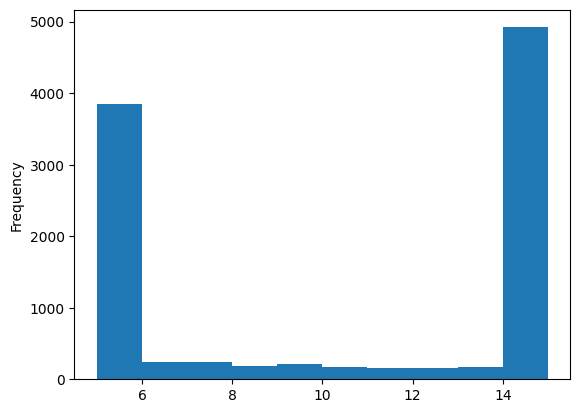

In [111]:
norm_days['norm_days'].plot.hist()

In [115]:
norms = final_df.copy()

In [116]:
norms = norms[['key2', 'run_month', 'month_date', 'Offtake Chain FC PSKU Forecast Vol']]

In [117]:
norms['total_days_in_month'] = norms['month_date'].dt.day

In [118]:
len_before_merge = len(norms)
norms = norms.merge(
    norm_days[['key2', 'norm_days']],
    on=['key2'],
    how='left'
)
assert len_before_merge == len(norms)
del len_before_merge

In [119]:
norms['safety_stock'] = norms['Offtake Chain FC PSKU Forecast Vol'] *  norms['norm_days'] / norms['total_days_in_month']

In [120]:
norms.isna().sum()

key2                                       0
run_month                                  0
month_date                                 0
Offtake Chain FC PSKU Forecast Vol    123394
total_days_in_month                        0
norm_days                             164178
safety_stock                          175030
dtype: int64

In [121]:
norms

,key2,run_month,month_date,Offtake Chain FC PSKU Forecast Vol,total_days_in_month,norm_days,safety_stock
0,Blinkit_ahmedabad a2 - feeder warehouse_718288,2025-11-30,2025-10-31,NaN,31,6.530321,NaN
1,Blinkit_ahmedabad a2 - feeder warehouse_718299,2025-11-30,2025-10-31,NaN,31,NaN,NaN
2,Blinkit_ahmedabad a2 - feeder warehouse_718308,2025-11-30,2025-10-31,NaN,31,NaN,NaN
3,Blinkit_ahmedabad a2 - feeder warehouse_718310,2025-11-30,2025-10-31,NaN,31,5.000000,NaN
4,Blinkit_ahmedabad a2 - feeder warehouse_718312,2025-11-30,2025-10-31,NaN,31,5.923442,NaN
...,...,...,...,...,...,...,...
235853,Zepto_pun-dry-mh2-koregaon_810673,2025-11-30,2026-04-30,0.0,30,NaN,NaN
235854,Zepto_pun-dry-mh2-koregaon_810674,2025-11-30,2026-04-30,0.0,30,NaN,NaN
235855,Zepto_pun-dry-mh2-koregaon_810685,2025-11-30,2026-04-30,0.0,30,15.000000,0.0
235856,Zepto_pun-dry-mh2-koregaon_810738,2025-11-30,2026-04-30,0.0,30,NaN,NaN


In [122]:
len_before_merge = len(final_df)
final_df = final_df.merge(
    norms.drop(['Offtake Chain FC PSKU Forecast Vol', 'total_days_in_month', 'norm_days'], axis=1).rename(columns={
        'safety_stock': 'norms_soh'
    }),
    on=['key2', 'run_month', 'month_date'],
    how='left'
)
assert len_before_merge == len(final_df)
del len_before_merge

In [123]:
norms['month_date'] = norms['month_date'] - MonthEnd(1)

In [124]:
len_before_merge = len(final_df)
final_df = final_df.merge(
    norms.drop(['Offtake Chain FC PSKU Forecast Vol', 'total_days_in_month'], axis=1),
    on=['key2', 'run_month', 'month_date'],
    how='left'
)
assert len_before_merge == len(final_df)
del len_before_merge

In [125]:
final_df.sort_values(
    by=['run_month', 'key2', 'month_date'], inplace=True
)

In [126]:
final_df['safety_stock'] = final_df['safety_stock'].fillna(0)

In [127]:
final_df.sort_values(by=['run_month', 'key2', 'month_date'], inplace=True)

In [128]:
norms

,key2,run_month,month_date,Offtake Chain FC PSKU Forecast Vol,total_days_in_month,norm_days,safety_stock
0,Blinkit_ahmedabad a2 - feeder warehouse_718288,2025-11-30,2025-09-30,NaN,31,6.530321,NaN
1,Blinkit_ahmedabad a2 - feeder warehouse_718299,2025-11-30,2025-09-30,NaN,31,NaN,NaN
2,Blinkit_ahmedabad a2 - feeder warehouse_718308,2025-11-30,2025-09-30,NaN,31,NaN,NaN
3,Blinkit_ahmedabad a2 - feeder warehouse_718310,2025-11-30,2025-09-30,NaN,31,5.000000,NaN
4,Blinkit_ahmedabad a2 - feeder warehouse_718312,2025-11-30,2025-09-30,NaN,31,5.923442,NaN
...,...,...,...,...,...,...,...
235853,Zepto_pun-dry-mh2-koregaon_810673,2025-11-30,2026-03-31,0.0,30,NaN,NaN
235854,Zepto_pun-dry-mh2-koregaon_810674,2025-11-30,2026-03-31,0.0,30,NaN,NaN
235855,Zepto_pun-dry-mh2-koregaon_810685,2025-11-30,2026-03-31,0.0,30,15.000000,0.0
235856,Zepto_pun-dry-mh2-koregaon_810738,2025-11-30,2026-03-31,0.0,30,NaN,NaN


In [129]:
chain_wise_max_soh_dates = soh_df.groupby(
    ['run_month', 'chain'], as_index=False
)['as_on_date'].max()

chain_wise_max_soh_dates

,run_month,chain,as_on_date
0,2025-07-31,Blinkit,2025-07-30
1,2025-07-31,Swiggy,2025-07-30
2,2025-07-31,Zepto,2025-07-30
3,2025-08-31,Blinkit,2025-08-30
4,2025-08-31,Swiggy,2025-08-30
5,2025-08-31,Zepto,2025-08-30
6,2025-09-30,Blinkit,2025-09-30
7,2025-09-30,Swiggy,2025-09-30
8,2025-09-30,Zepto,2025-09-30
9,2025-10-31,Blinkit,2025-10-31


In [130]:
chain_wise_max_soh_dates = (
    chain_wise_max_soh_dates
    .groupby('chain')
    .apply(lambda x: dict(zip(x['run_month'], x['as_on_date'])))
    .to_dict()
)

In [131]:
last_date_soh = pd.DataFrame()

for c in chain_wise_max_soh_dates.keys():
    for rm in chain_wise_max_soh_dates[c].keys():
        last_date_soh = pd.concat([
            last_date_soh,
            soh_df[
                (soh_df['chain'] == c) &
                (soh_df['as_on_date'] == chain_wise_max_soh_dates[c][rm])
            ]
        ])

In [132]:
last_date_soh['as_on_date'] = last_date_soh['as_on_date'] + MonthEnd(0)

In [133]:
len_before_merge = len(final_df)
final_df = final_df.merge(
    last_date_soh[['key2', 'as_on_date', 'current_soh']].rename(
        columns={
            'as_on_date': 'month_date',
            'current_soh': 'Actual Closing SOH'
        }
    ),
    on=['key2', 'month_date'],
    how='left'
)
assert len_before_merge == len(final_df)
del len_before_merge

In [134]:
final_df.sort_values(by=['run_month', 'key2', 'month_date'], inplace=True)

In [135]:
final_df

,key2,chain,facility_name,parent_material_code,material_group_code,run_month,month_date,pri_actuals_vol_rum,sec_apo_plan_vol_rum,Primary P3M,...,Contribution,Final Contribution,Offtake Chain FC PSKU,M month,Offtake Chain PSKU Forecast Vol,Offtake Chain FC PSKU Forecast Vol,norms_soh,norm_days,safety_stock,Actual Closing SOH
0,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,2025-11-30,2025-10-31,5.784,6.2572,7.952,...,0.129368,0.129368,8.579435,NaN,NaN,NaN,NaN,6.530321,1.645897,0.402
1,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,2025-11-30,2025-11-30,3.864,7.7639,6.840,...,0.117817,0.117817,3.767090,M,64.177146,7.561177,1.645897,6.530321,1.757010,0.402
2,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,2025-11-30,2025-12-31,0.000,0.0000,6.840,...,0.117817,0.117817,NaN,M+1,70.793361,8.340681,1.757010,6.530321,1.747948,NaN
3,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,2025-11-30,2026-01-31,0.000,0.0000,6.840,...,0.117817,0.117817,NaN,M+2,70.428202,8.297659,1.747948,6.530321,1.964115,NaN
4,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,2025-11-30,2026-02-28,0.000,0.0000,6.840,...,0.117817,0.117817,NaN,M+3,71.479498,8.421520,1.964115,6.530321,1.971552,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235853,Zepto_pun-dry-mh2-koregaon_810805,Zepto,pun-dry-mh2-koregaon,810805,PABABY_GM,2025-11-30,2025-12-31,0.000,0.0000,0.000,...,NaN,0.058824,NaN,M+1,NaN,NaN,NaN,NaN,0.000000,NaN
235854,Zepto_pun-dry-mh2-koregaon_810805,Zepto,pun-dry-mh2-koregaon,810805,PABABY_GM,2025-11-30,2026-01-31,0.000,0.0000,0.000,...,NaN,0.058824,NaN,M+2,NaN,NaN,NaN,NaN,0.000000,NaN
235855,Zepto_pun-dry-mh2-koregaon_810805,Zepto,pun-dry-mh2-koregaon,810805,PABABY_GM,2025-11-30,2026-02-28,0.000,0.0000,0.000,...,NaN,0.058824,NaN,M+3,NaN,NaN,NaN,NaN,0.000000,NaN
235856,Zepto_pun-dry-mh2-koregaon_810805,Zepto,pun-dry-mh2-koregaon,810805,PABABY_GM,2025-11-30,2026-03-31,0.000,0.0000,0.000,...,NaN,0.058824,NaN,M+4,NaN,NaN,NaN,NaN,0.000000,NaN


In [136]:
final_df['Actual Closing SOH_Lag_1'] = final_df.groupby(
    ['run_month', 'key2']
)['Actual Closing SOH'].shift(1)

In [137]:
final_df['safety_stock'].sum()

205112.98817725183

In [138]:
final_df['Assumed Closing SOH'] = np.where(
    final_df['M month'] == 'M',  
    final_df['Actual Closing SOH_Lag_1'].fillna(0) + final_df['sec_apo_plan_vol_rum'].fillna(0) \
    - final_df['Offtake Chain FC PSKU Forecast Vol'].fillna(0),
    final_df['safety_stock']
)

In [139]:
final_df['Assumed Closing SOH'] = final_df['Assumed Closing SOH'].clip(lower=0.0)

In [140]:
final_df['Assumed Closing SOH_Lag_1'] = final_df.groupby(
    ['run_month', 'key2']
)['Assumed Closing SOH'].shift(1)

In [141]:
final_df = final_df[
    ~final_df['material_group_code'].isin(['NC FREE', 'HC FREE'])
]

In [142]:
final_df

,key2,chain,facility_name,parent_material_code,material_group_code,run_month,month_date,pri_actuals_vol_rum,sec_apo_plan_vol_rum,Primary P3M,...,M month,Offtake Chain PSKU Forecast Vol,Offtake Chain FC PSKU Forecast Vol,norms_soh,norm_days,safety_stock,Actual Closing SOH,Actual Closing SOH_Lag_1,Assumed Closing SOH,Assumed Closing SOH_Lag_1
0,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,2025-11-30,2025-10-31,5.784,6.2572,7.952,...,NaN,NaN,NaN,NaN,6.530321,1.645897,0.402,NaN,1.645897,NaN
1,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,2025-11-30,2025-11-30,3.864,7.7639,6.840,...,M,64.177146,7.561177,1.645897,6.530321,1.757010,0.402,0.402,0.604723,1.645897
2,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,2025-11-30,2025-12-31,0.000,0.0000,6.840,...,M+1,70.793361,8.340681,1.757010,6.530321,1.747948,NaN,0.402,1.747948,0.604723
3,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,2025-11-30,2026-01-31,0.000,0.0000,6.840,...,M+2,70.428202,8.297659,1.747948,6.530321,1.964115,NaN,NaN,1.964115,1.747948
4,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,2025-11-30,2026-02-28,0.000,0.0000,6.840,...,M+3,71.479498,8.421520,1.964115,6.530321,1.971552,NaN,NaN,1.971552,1.964115
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235853,Zepto_pun-dry-mh2-koregaon_810805,Zepto,pun-dry-mh2-koregaon,810805,PABABY_GM,2025-11-30,2025-12-31,0.000,0.0000,0.000,...,M+1,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,0.000000,0.000000
235854,Zepto_pun-dry-mh2-koregaon_810805,Zepto,pun-dry-mh2-koregaon,810805,PABABY_GM,2025-11-30,2026-01-31,0.000,0.0000,0.000,...,M+2,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,0.000000,0.000000
235855,Zepto_pun-dry-mh2-koregaon_810805,Zepto,pun-dry-mh2-koregaon,810805,PABABY_GM,2025-11-30,2026-02-28,0.000,0.0000,0.000,...,M+3,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,0.000000,0.000000
235856,Zepto_pun-dry-mh2-koregaon_810805,Zepto,pun-dry-mh2-koregaon,810805,PABABY_GM,2025-11-30,2026-03-31,0.000,0.0000,0.000,...,M+4,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,0.000000,0.000000


In [143]:
soh_df['as_on_date'].max()

Timestamp('2025-11-19 00:00:00')

### Add P3M, LY

In [144]:
actuals_df = plan_actuals_df.copy()
actuals_df['month_date'] = actuals_df['month_date'] + MonthEnd(0)

In [145]:
actuals_df = actuals_df.groupby(
    ['key2', 'month_date'], as_index=False
)[['pri_actuals_vol_rum', 'sec_actuals_vol_rum']].sum()

In [146]:
actuals_df.duplicated(subset=['key2', 'month_date']).sum()

0

In [147]:
actuals_df['month_date'].min()

Timestamp('2024-01-31 00:00:00')

In [148]:
actuals_df.sort_values(by=['key2', 'month_date'], inplace=True)

In [149]:
actuals_df['Primary P3M redundant'] = actuals_df.groupby(
['key2'], as_index = False, group_keys = False)['pri_actuals_vol_rum'].shift(1)\
                            .rolling(window=3, min_periods=3).mean()

In [150]:
len_before_merge = len(final_df)
final_df = final_df.merge(
    actuals_df.rename(columns={
        'pri_actuals_vol_rum': 'Primary Actuals Vol',
        'sec_actuals_vol_rum': 'Sec Actuals Vol'
    }),
    on=['key2', 'month_date'],
    how='left'
)
assert len_before_merge == len(final_df)
del len_before_merge

In [151]:
final_df.isna().sum()

key2                                           0
chain                                          0
facility_name                               6104
parent_material_code                           0
material_group_code                            0
run_month                                      0
month_date                                     0
pri_actuals_vol_rum                         1226
sec_apo_plan_vol_rum                        1226
Primary P3M                                 1226
key                                            0
Offtake Chain PSKU                        202827
Primary Actuals Chain PSKU P3M Sum Vol         0
Group Size                                     0
Fallback Contribution                          0
Contribution                              129592
Final Contribution                             0
Offtake Chain FC PSKU                     202827
M month                                    33694
Offtake Chain PSKU Forecast Vol           123394
Offtake Chain FC PSK

In [152]:
plan_actuals_df

,month_date,key2,chain,facility_name,parent_material_code,material_group_code,pri_actuals_vol_rum,pri_apo_plan_vol_rum,sec_apo_plan_vol_rum,sec_actuals_vol_rum,Primary P3M
0,2024-09-30,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,1.728,0.000000,0.0,1.728,NaN
1,2024-10-31,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,8.664,0.607765,0.0,8.664,1.728
2,2024-11-30,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,2.832,0.260008,0.0,2.832,5.196
3,2024-12-31,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,7.320,0.550052,0.0,7.320,4.408
4,2025-01-31,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,5.880,0.675054,0.0,5.880,6.272
...,...,...,...,...,...,...,...,...,...,...,...
633877,2025-12-31,Zepto_pun-dry-mh2-koregaon_810805,Zepto,pun-dry-mh2-koregaon,810805,PABABY_GM,0.000,0.000000,0.0,0.000,0.000
633878,2026-01-31,Zepto_pun-dry-mh2-koregaon_810805,Zepto,pun-dry-mh2-koregaon,810805,PABABY_GM,0.000,0.000000,0.0,0.000,0.000
633879,2026-02-28,Zepto_pun-dry-mh2-koregaon_810805,Zepto,pun-dry-mh2-koregaon,810805,PABABY_GM,0.000,0.000000,0.0,0.000,0.000
633880,2026-03-31,Zepto_pun-dry-mh2-koregaon_810805,Zepto,pun-dry-mh2-koregaon,810805,PABABY_GM,0.000,0.000000,0.0,0.000,0.000


In [153]:
final_df

,key2,chain,facility_name,parent_material_code,material_group_code,run_month,month_date,pri_actuals_vol_rum,sec_apo_plan_vol_rum,Primary P3M,...,norms_soh,norm_days,safety_stock,Actual Closing SOH,Actual Closing SOH_Lag_1,Assumed Closing SOH,Assumed Closing SOH_Lag_1,Primary Actuals Vol,Sec Actuals Vol,Primary P3M redundant
0,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,2025-11-30,2025-10-31,5.784,6.2572,7.952,...,NaN,6.530321,1.645897,0.402,NaN,1.645897,NaN,5.784,5.784,7.952
1,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,2025-11-30,2025-11-30,3.864,7.7639,6.840,...,1.645897,6.530321,1.757010,0.402,0.402,0.604723,1.645897,3.864,0.000,6.840
2,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,2025-11-30,2025-12-31,0.000,0.0000,6.840,...,1.757010,6.530321,1.747948,NaN,0.402,1.747948,0.604723,0.000,0.000,6.664
3,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,2025-11-30,2026-01-31,0.000,0.0000,6.840,...,1.747948,6.530321,1.964115,NaN,NaN,1.964115,1.747948,0.000,0.000,3.216
4,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,2025-11-30,2026-02-28,0.000,0.0000,6.840,...,1.964115,6.530321,1.971552,NaN,NaN,1.971552,1.964115,0.000,0.000,1.288
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235853,Zepto_pun-dry-mh2-koregaon_810805,Zepto,pun-dry-mh2-koregaon,810805,PABABY_GM,2025-11-30,2025-12-31,0.000,0.0000,0.000,...,NaN,NaN,0.000000,NaN,NaN,0.000000,0.000000,0.000,0.000,0.000
235854,Zepto_pun-dry-mh2-koregaon_810805,Zepto,pun-dry-mh2-koregaon,810805,PABABY_GM,2025-11-30,2026-01-31,0.000,0.0000,0.000,...,NaN,NaN,0.000000,NaN,NaN,0.000000,0.000000,0.000,0.000,0.000
235855,Zepto_pun-dry-mh2-koregaon_810805,Zepto,pun-dry-mh2-koregaon,810805,PABABY_GM,2025-11-30,2026-02-28,0.000,0.0000,0.000,...,NaN,NaN,0.000000,NaN,NaN,0.000000,0.000000,0.000,0.000,0.000
235856,Zepto_pun-dry-mh2-koregaon_810805,Zepto,pun-dry-mh2-koregaon,810805,PABABY_GM,2025-11-30,2026-03-31,0.000,0.0000,0.000,...,NaN,NaN,0.000000,NaN,NaN,0.000000,0.000000,0.000,0.000,0.000


In [154]:
ly_actuals_df = actuals_df.copy()

In [155]:
ly_actuals_df['month_date'] = ly_actuals_df['month_date'] + MonthEnd(12)

In [156]:
ly_actuals_df.rename(columns={
        'pri_actuals_vol_rum': 'LY Primary Actuals Vol',
        'sec_actuals_vol_rum': 'LY Sec Actuals Vol',
        'Primary P3M redundant': 'LY Primary P3M'
    })

,key2,month_date,LY Primary Actuals Vol,LY Sec Actuals Vol,LY Primary P3M
0,Blinkit_ahmedabad a2 - feeder warehouse_718288,2025-09-30,1.728,1.728,NaN
1,Blinkit_ahmedabad a2 - feeder warehouse_718288,2025-10-31,8.664,8.664,NaN
2,Blinkit_ahmedabad a2 - feeder warehouse_718288,2025-11-30,2.832,2.832,NaN
3,Blinkit_ahmedabad a2 - feeder warehouse_718288,2025-12-31,7.320,7.320,4.408
4,Blinkit_ahmedabad a2 - feeder warehouse_718288,2026-01-31,5.880,5.880,6.272
...,...,...,...,...,...
633877,Zepto_pun-dry-mh2-koregaon_810805,2026-12-31,0.000,0.000,0.000
633878,Zepto_pun-dry-mh2-koregaon_810805,2027-01-31,0.000,0.000,0.000
633879,Zepto_pun-dry-mh2-koregaon_810805,2027-02-28,0.000,0.000,0.000
633880,Zepto_pun-dry-mh2-koregaon_810805,2027-03-31,0.000,0.000,0.000


In [157]:
len_before_merge = len(final_df)
final_df = final_df.merge(
    ly_actuals_df.rename(columns={
        'pri_actuals_vol_rum': 'LY Primary Actuals Vol',
        'sec_actuals_vol_rum': 'LY Sec Actuals Vol',
        'Primary P3M redundant': 'LY Primary P3M'
    }),
    on=['key2', 'month_date'],
    how='left'
)
assert len_before_merge == len(final_df)
del len_before_merge

In [158]:
final_df[final_df['Contribution'].isna()]

,key2,chain,facility_name,parent_material_code,material_group_code,run_month,month_date,pri_actuals_vol_rum,sec_apo_plan_vol_rum,Primary P3M,...,Actual Closing SOH,Actual Closing SOH_Lag_1,Assumed Closing SOH,Assumed Closing SOH_Lag_1,Primary Actuals Vol,Sec Actuals Vol,Primary P3M redundant,LY Primary Actuals Vol,LY Sec Actuals Vol,LY Primary P3M
7,Blinkit_ahmedabad a2 - feeder warehouse_718299,Blinkit,ahmedabad a2 - feeder warehouse,718299,PCNO(R),2025-11-30,2025-10-31,0.0,0.0,0.0,...,NaN,NaN,0.0,NaN,0.0,0.0,0.0,0.0,0.0,NaN
8,Blinkit_ahmedabad a2 - feeder warehouse_718299,Blinkit,ahmedabad a2 - feeder warehouse,718299,PCNO(R),2025-11-30,2025-11-30,0.0,0.0,0.0,...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
9,Blinkit_ahmedabad a2 - feeder warehouse_718299,Blinkit,ahmedabad a2 - feeder warehouse,718299,PCNO(R),2025-11-30,2025-12-31,0.0,0.0,0.0,...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
10,Blinkit_ahmedabad a2 - feeder warehouse_718299,Blinkit,ahmedabad a2 - feeder warehouse,718299,PCNO(R),2025-11-30,2026-01-31,0.0,0.0,0.0,...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11,Blinkit_ahmedabad a2 - feeder warehouse_718299,Blinkit,ahmedabad a2 - feeder warehouse,718299,PCNO(R),2025-11-30,2026-02-28,0.0,0.0,0.0,...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235853,Zepto_pun-dry-mh2-koregaon_810805,Zepto,pun-dry-mh2-koregaon,810805,PABABY_GM,2025-11-30,2025-12-31,0.0,0.0,0.0,...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
235854,Zepto_pun-dry-mh2-koregaon_810805,Zepto,pun-dry-mh2-koregaon,810805,PABABY_GM,2025-11-30,2026-01-31,0.0,0.0,0.0,...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
235855,Zepto_pun-dry-mh2-koregaon_810805,Zepto,pun-dry-mh2-koregaon,810805,PABABY_GM,2025-11-30,2026-02-28,0.0,0.0,0.0,...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
235856,Zepto_pun-dry-mh2-koregaon_810805,Zepto,pun-dry-mh2-koregaon,810805,PABABY_GM,2025-11-30,2026-03-31,0.0,0.0,0.0,...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN


In [159]:
final_df['Contribution'].isna()

0         False
1         False
2         False
3         False
4         False
          ...  
235853     True
235854     True
235855     True
235856     True
235857     True
Name: Contribution, Length: 235858, dtype: bool

In [160]:
final_df[final_df['Contribution'].isna()]

,key2,chain,facility_name,parent_material_code,material_group_code,run_month,month_date,pri_actuals_vol_rum,sec_apo_plan_vol_rum,Primary P3M,...,Actual Closing SOH,Actual Closing SOH_Lag_1,Assumed Closing SOH,Assumed Closing SOH_Lag_1,Primary Actuals Vol,Sec Actuals Vol,Primary P3M redundant,LY Primary Actuals Vol,LY Sec Actuals Vol,LY Primary P3M
7,Blinkit_ahmedabad a2 - feeder warehouse_718299,Blinkit,ahmedabad a2 - feeder warehouse,718299,PCNO(R),2025-11-30,2025-10-31,0.0,0.0,0.0,...,NaN,NaN,0.0,NaN,0.0,0.0,0.0,0.0,0.0,NaN
8,Blinkit_ahmedabad a2 - feeder warehouse_718299,Blinkit,ahmedabad a2 - feeder warehouse,718299,PCNO(R),2025-11-30,2025-11-30,0.0,0.0,0.0,...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
9,Blinkit_ahmedabad a2 - feeder warehouse_718299,Blinkit,ahmedabad a2 - feeder warehouse,718299,PCNO(R),2025-11-30,2025-12-31,0.0,0.0,0.0,...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
10,Blinkit_ahmedabad a2 - feeder warehouse_718299,Blinkit,ahmedabad a2 - feeder warehouse,718299,PCNO(R),2025-11-30,2026-01-31,0.0,0.0,0.0,...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11,Blinkit_ahmedabad a2 - feeder warehouse_718299,Blinkit,ahmedabad a2 - feeder warehouse,718299,PCNO(R),2025-11-30,2026-02-28,0.0,0.0,0.0,...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235853,Zepto_pun-dry-mh2-koregaon_810805,Zepto,pun-dry-mh2-koregaon,810805,PABABY_GM,2025-11-30,2025-12-31,0.0,0.0,0.0,...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
235854,Zepto_pun-dry-mh2-koregaon_810805,Zepto,pun-dry-mh2-koregaon,810805,PABABY_GM,2025-11-30,2026-01-31,0.0,0.0,0.0,...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
235855,Zepto_pun-dry-mh2-koregaon_810805,Zepto,pun-dry-mh2-koregaon,810805,PABABY_GM,2025-11-30,2026-02-28,0.0,0.0,0.0,...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
235856,Zepto_pun-dry-mh2-koregaon_810805,Zepto,pun-dry-mh2-koregaon,810805,PABABY_GM,2025-11-30,2026-03-31,0.0,0.0,0.0,...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN


In [165]:
offtakes_monthly_df['month_date'].max()

Timestamp('2025-09-30 00:00:00')

In [110]:
final_offtakes_historical_df = offtakes_monthly_df.copy()

In [168]:
final_offtakes_historical_df

,chain,parent_material_code,material_group_code,month_date,offtake_vol_rum
0,Blinkit,718288,SAFF GOLD,2023-01-31,22.584
1,Blinkit,718288,SAFF GOLD,2023-02-28,17.568
2,Blinkit,718288,SAFF GOLD,2023-03-31,25.332
3,Blinkit,718288,SAFF GOLD,2023-04-30,21.888
4,Blinkit,718288,SAFF GOLD,2023-05-31,15.860
...,...,...,...,...,...
12916,Zepto,810522,SAF_CDPRS,2025-10-31,0.103
12917,Zepto,810673,PA_ESS_HO,2025-10-31,0.168
12918,Zepto,810674,PA_ESS_HO,2025-10-31,0.168
12919,Zepto,810685,SAF-MUSLI,2025-10-31,0.034


In [169]:
final_offtakes_historical_df.duplicated(subset=['chain', 'parent_material_code', 'month_date']).sum()

0

In [170]:
final_offtakes_historical_df['key'] = final_offtakes_historical_df[['chain', 'parent_material_code']].astype(str).agg(
    '_'.join, axis=1
)

In [171]:

final_offtakes_historical_df.sort_values(
    by=['key', 'month_date'], inplace=True
)

In [172]:
final_offtakes_historical_df['P3M'] = final_offtakes_historical_df.groupby(
    ['key'], as_index = False, group_keys = False)['offtake_vol_rum'].shift(1)\
                                .rolling(window=3, min_periods=3).mean()

In [173]:
len_before_merge = len(final_df)
final_df = final_df.merge(
    final_offtakes_historical_df[['key', 'month_date', 'offtake_vol_rum', 'P3M']].rename(
        columns={'P3M': 'Offtake P3M', 'offtake_vol_rum': 'Offtake Actuals Vol'}
    ),
    on=['key', 'month_date'],
    how='left'
)
assert len_before_merge == len(final_df)
del len_before_merge

In [174]:
ly_final_offtakes_historical_df = final_offtakes_historical_df.copy()

In [175]:
ly_final_offtakes_historical_df['month_date'].min()

Timestamp('2023-01-31 00:00:00')

In [176]:
ly_final_offtakes_historical_df['month_date'] = ly_final_offtakes_historical_df['month_date'] + MonthEnd(12)
ly_final_offtakes_historical_df.head()

,chain,parent_material_code,material_group_code,month_date,offtake_vol_rum,key,P3M
0,Blinkit,718288,SAFF GOLD,2024-01-31,22.584,Blinkit_718288,NaN
1,Blinkit,718288,SAFF GOLD,2024-02-29,17.568,Blinkit_718288,NaN
2,Blinkit,718288,SAFF GOLD,2024-03-31,25.332,Blinkit_718288,NaN
3,Blinkit,718288,SAFF GOLD,2024-04-30,21.888,Blinkit_718288,21.828
4,Blinkit,718288,SAFF GOLD,2024-05-31,15.860,Blinkit_718288,21.596


In [177]:
len_before_merge = len(final_df)
final_df = final_df.merge(
    ly_final_offtakes_historical_df[['key', 'month_date', 'offtake_vol_rum', 'P3M']].rename(
        columns={'P3M': 'LY Offtake P3M', 'offtake_vol_rum': 'LY Offtake Actuals Vol'}
    ),
    on=['key', 'month_date'],
    how='left'
)
assert len_before_merge == len(final_df)
del len_before_merge

In [178]:
final_df.sort_values(by=['run_month', 'key2', 'month_date'], inplace=True)

In [179]:
for col in ['Primary P3M', 'LY Primary P3M', 'Offtake P3M', 'LY Offtake P3M', 'Primary P3M redundant']:
    # if not 'LY' in col:  'LY P6M',
    final_df.loc[final_df['month_date'] > final_df['run_month'], [col]] = np.nan
    final_df[col] = final_df.groupby(['run_month', 'key2'], as_index = True, group_keys = False)[col].apply(
        lambda x: x.ffill()
    )

In [180]:
final_offtakes_historical_df

,chain,parent_material_code,material_group_code,month_date,offtake_vol_rum,key,P3M
0,Blinkit,718288,SAFF GOLD,2023-01-31,22.584,Blinkit_718288,NaN
1,Blinkit,718288,SAFF GOLD,2023-02-28,17.568,Blinkit_718288,NaN
2,Blinkit,718288,SAFF GOLD,2023-03-31,25.332,Blinkit_718288,NaN
3,Blinkit,718288,SAFF GOLD,2023-04-30,21.888,Blinkit_718288,21.828000
4,Blinkit,718288,SAFF GOLD,2023-05-31,15.860,Blinkit_718288,21.596000
...,...,...,...,...,...,...,...
12323,Zepto,810685,SAF-MUSLI,2025-09-30,0.012,Zepto_810685,0.008533
12919,Zepto,810685,SAF-MUSLI,2025-10-31,0.034,Zepto_810685,0.011867
12324,Zepto,810738,PABABY_GM,2025-08-31,0.724,Zepto_810738,NaN
12325,Zepto,810738,PABABY_GM,2025-09-30,4.344,Zepto_810738,NaN


In [181]:
final_offtakes_historical_df.sort_values(by=['key', 'month_date'], inplace=True)

In [182]:
# final_offtakes_historical_df['OT_Lag_1'] = final_offtakes_historical_df.groupby(
#     ['material_group_code', 'key']
# )['offtake_vol_rum'].shift(1)

# final_offtakes_historical_df['OT_Lag_2'] = final_offtakes_historical_df.groupby(
#     ['material_group_code', 'key']
# )['offtake_vol_rum'].shift(2)

# final_offtakes_historical_df['OT_Lag_3'] = final_offtakes_historical_df.groupby(
#     ['material_group_code', 'key']
# )['offtake_vol_rum'].shift(3)

In [183]:
# del final_df['OT_Lag_1'], final_df['OT_Lag_2'], final_df['OT_Lag_3']

In [184]:
# len_before_merge = len(final_df)
# final_df = final_df.merge(
#     final_offtakes_historical_df[['key', 'month_date', 'OT_Lag_1', 'OT_Lag_2', 'OT_Lag_3']].rename(
#         columns={'month_date': 'run_month'}
#     ),
#     on=['key', 'run_month'],
#     how='left'
# )
# assert len_before_merge == len(final_df)
# del len_before_merge

In [185]:
lags_df = plan_actuals_df.copy()

In [186]:
lags_df.sort_values(by=['key2', 'month_date'], inplace=True)

In [187]:
lags_df

,month_date,key2,chain,facility_name,parent_material_code,material_group_code,pri_actuals_vol_rum,pri_apo_plan_vol_rum,sec_apo_plan_vol_rum,sec_actuals_vol_rum,Primary P3M
0,2024-09-30,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,1.728,0.000000,0.0,1.728,NaN
1,2024-10-31,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,8.664,0.607765,0.0,8.664,1.728
2,2024-11-30,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,2.832,0.260008,0.0,2.832,5.196
3,2024-12-31,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,7.320,0.550052,0.0,7.320,4.408
4,2025-01-31,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,5.880,0.675054,0.0,5.880,6.272
...,...,...,...,...,...,...,...,...,...,...,...
633877,2025-12-31,Zepto_pun-dry-mh2-koregaon_810805,Zepto,pun-dry-mh2-koregaon,810805,PABABY_GM,0.000,0.000000,0.0,0.000,0.000
633878,2026-01-31,Zepto_pun-dry-mh2-koregaon_810805,Zepto,pun-dry-mh2-koregaon,810805,PABABY_GM,0.000,0.000000,0.0,0.000,0.000
633879,2026-02-28,Zepto_pun-dry-mh2-koregaon_810805,Zepto,pun-dry-mh2-koregaon,810805,PABABY_GM,0.000,0.000000,0.0,0.000,0.000
633880,2026-03-31,Zepto_pun-dry-mh2-koregaon_810805,Zepto,pun-dry-mh2-koregaon,810805,PABABY_GM,0.000,0.000000,0.0,0.000,0.000


In [188]:
lags_df['Primary_Lag_2'] = lags_df.groupby(
    ['material_group_code', 'key2']
)['pri_actuals_vol_rum'].shift(1)

lags_df['Primary_Lag_3'] = lags_df.groupby(
    ['material_group_code', 'key2']
)['pri_actuals_vol_rum'].shift(2)

In [189]:
lags_df['month_date'] = lags_df['month_date'] + MonthEnd(1)

In [190]:
len_before_merge = len(final_df)
final_df = final_df.merge(
    lags_df[['key2', 'month_date', 'pri_actuals_vol_rum', 'Primary_Lag_2', 'Primary_Lag_3']].rename(columns={
        'month_date': 'run_month',
        'pri_actuals_vol_rum': 'Primary_Lag_1'
    }),
    on=['key2', 'run_month'],
    how='left'
)
assert len_before_merge == len(final_df)
del len_before_merge

In [191]:
final_df

,key2,chain,facility_name,parent_material_code,material_group_code,run_month,month_date,pri_actuals_vol_rum,sec_apo_plan_vol_rum,Primary P3M,...,LY Primary Actuals Vol,LY Sec Actuals Vol,LY Primary P3M,Offtake Actuals Vol,Offtake P3M,LY Offtake Actuals Vol,LY Offtake P3M,Primary_Lag_1,Primary_Lag_2,Primary_Lag_3
0,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,2025-11-30,2025-10-31,5.784,6.2572,7.952,...,8.664,8.664,NaN,66.318,56.036,41.556,27.651667,5.784,10.344,4.392
1,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,2025-11-30,2025-11-30,3.864,7.7639,6.840,...,2.832,2.832,NaN,NaN,56.036,35.844,32.292000,5.784,10.344,4.392
2,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,2025-11-30,2025-12-31,0.000,0.0000,6.840,...,7.320,7.320,NaN,NaN,56.036,44.304,32.292000,5.784,10.344,4.392
3,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,2025-11-30,2026-01-31,0.000,0.0000,6.840,...,5.880,5.880,NaN,NaN,56.036,44.688,32.292000,5.784,10.344,4.392
4,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,2025-11-30,2026-02-28,0.000,0.0000,6.840,...,8.784,8.784,NaN,NaN,56.036,44.646,32.292000,5.784,10.344,4.392
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235853,Zepto_pun-dry-mh2-koregaon_810805,Zepto,pun-dry-mh2-koregaon,810805,PABABY_GM,2025-11-30,2025-12-31,0.000,0.0000,0.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000,0.000,0.000
235854,Zepto_pun-dry-mh2-koregaon_810805,Zepto,pun-dry-mh2-koregaon,810805,PABABY_GM,2025-11-30,2026-01-31,0.000,0.0000,0.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000,0.000,0.000
235855,Zepto_pun-dry-mh2-koregaon_810805,Zepto,pun-dry-mh2-koregaon,810805,PABABY_GM,2025-11-30,2026-02-28,0.000,0.0000,0.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000,0.000,0.000
235856,Zepto_pun-dry-mh2-koregaon_810805,Zepto,pun-dry-mh2-koregaon,810805,PABABY_GM,2025-11-30,2026-03-31,0.000,0.0000,0.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000,0.000,0.000


In [192]:
lags_final_offtakes_historical_df = final_offtakes_historical_df.copy()

lags_final_offtakes_historical_df.sort_values(by=['key', 'month_date'], inplace=True)
lags_final_offtakes_historical_df['OT_Lag_2'] = lags_final_offtakes_historical_df.groupby(
    ['material_group_code', 'key']
)['offtake_vol_rum'].shift(1)

lags_final_offtakes_historical_df['OT_Lag_3'] = lags_final_offtakes_historical_df.groupby(
    ['material_group_code', 'key']
)['offtake_vol_rum'].shift(2)

In [193]:
# del final_df['OT_Lag_1'], final_df['OT_Lag_2'], final_df['OT_Lag_3']

In [194]:
lags_final_offtakes_historical_df['month_date'] = lags_final_offtakes_historical_df['month_date'] + MonthEnd(1)

In [195]:
len_before_merge = len(final_df)
final_df = final_df.merge(
    lags_final_offtakes_historical_df[['key', 'month_date', 'offtake_vol_rum', 'OT_Lag_2', 'OT_Lag_3']].rename(columns={
        'month_date': 'run_month',
        'offtake_vol_rum': 'OT_Lag_1'
    }),
    on=['key', 'run_month'],
    how='left'
)
assert len_before_merge == len(final_df)
del len_before_merge

In [196]:
final_df

,key2,chain,facility_name,parent_material_code,material_group_code,run_month,month_date,pri_actuals_vol_rum,sec_apo_plan_vol_rum,Primary P3M,...,Offtake Actuals Vol,Offtake P3M,LY Offtake Actuals Vol,LY Offtake P3M,Primary_Lag_1,Primary_Lag_2,Primary_Lag_3,OT_Lag_1,OT_Lag_2,OT_Lag_3
0,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,2025-11-30,2025-10-31,5.784,6.2572,7.952,...,66.318,56.036,41.556,27.651667,5.784,10.344,4.392,66.318,52.722,58.344
1,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,2025-11-30,2025-11-30,3.864,7.7639,6.840,...,NaN,56.036,35.844,32.292000,5.784,10.344,4.392,66.318,52.722,58.344
2,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,2025-11-30,2025-12-31,0.000,0.0000,6.840,...,NaN,56.036,44.304,32.292000,5.784,10.344,4.392,66.318,52.722,58.344
3,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,2025-11-30,2026-01-31,0.000,0.0000,6.840,...,NaN,56.036,44.688,32.292000,5.784,10.344,4.392,66.318,52.722,58.344
4,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,2025-11-30,2026-02-28,0.000,0.0000,6.840,...,NaN,56.036,44.646,32.292000,5.784,10.344,4.392,66.318,52.722,58.344
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235853,Zepto_pun-dry-mh2-koregaon_810805,Zepto,pun-dry-mh2-koregaon,810805,PABABY_GM,2025-11-30,2025-12-31,0.000,0.0000,0.000,...,NaN,NaN,NaN,NaN,0.000,0.000,0.000,NaN,NaN,NaN
235854,Zepto_pun-dry-mh2-koregaon_810805,Zepto,pun-dry-mh2-koregaon,810805,PABABY_GM,2025-11-30,2026-01-31,0.000,0.0000,0.000,...,NaN,NaN,NaN,NaN,0.000,0.000,0.000,NaN,NaN,NaN
235855,Zepto_pun-dry-mh2-koregaon_810805,Zepto,pun-dry-mh2-koregaon,810805,PABABY_GM,2025-11-30,2026-02-28,0.000,0.0000,0.000,...,NaN,NaN,NaN,NaN,0.000,0.000,0.000,NaN,NaN,NaN
235856,Zepto_pun-dry-mh2-koregaon_810805,Zepto,pun-dry-mh2-koregaon,810805,PABABY_GM,2025-11-30,2026-03-31,0.000,0.0000,0.000,...,NaN,NaN,NaN,NaN,0.000,0.000,0.000,NaN,NaN,NaN


In [197]:
final_df

,key2,chain,facility_name,parent_material_code,material_group_code,run_month,month_date,pri_actuals_vol_rum,sec_apo_plan_vol_rum,Primary P3M,...,Offtake Actuals Vol,Offtake P3M,LY Offtake Actuals Vol,LY Offtake P3M,Primary_Lag_1,Primary_Lag_2,Primary_Lag_3,OT_Lag_1,OT_Lag_2,OT_Lag_3
0,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,2025-11-30,2025-10-31,5.784,6.2572,7.952,...,66.318,56.036,41.556,27.651667,5.784,10.344,4.392,66.318,52.722,58.344
1,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,2025-11-30,2025-11-30,3.864,7.7639,6.840,...,NaN,56.036,35.844,32.292000,5.784,10.344,4.392,66.318,52.722,58.344
2,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,2025-11-30,2025-12-31,0.000,0.0000,6.840,...,NaN,56.036,44.304,32.292000,5.784,10.344,4.392,66.318,52.722,58.344
3,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,2025-11-30,2026-01-31,0.000,0.0000,6.840,...,NaN,56.036,44.688,32.292000,5.784,10.344,4.392,66.318,52.722,58.344
4,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,2025-11-30,2026-02-28,0.000,0.0000,6.840,...,NaN,56.036,44.646,32.292000,5.784,10.344,4.392,66.318,52.722,58.344
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235853,Zepto_pun-dry-mh2-koregaon_810805,Zepto,pun-dry-mh2-koregaon,810805,PABABY_GM,2025-11-30,2025-12-31,0.000,0.0000,0.000,...,NaN,NaN,NaN,NaN,0.000,0.000,0.000,NaN,NaN,NaN
235854,Zepto_pun-dry-mh2-koregaon_810805,Zepto,pun-dry-mh2-koregaon,810805,PABABY_GM,2025-11-30,2026-01-31,0.000,0.0000,0.000,...,NaN,NaN,NaN,NaN,0.000,0.000,0.000,NaN,NaN,NaN
235855,Zepto_pun-dry-mh2-koregaon_810805,Zepto,pun-dry-mh2-koregaon,810805,PABABY_GM,2025-11-30,2026-02-28,0.000,0.0000,0.000,...,NaN,NaN,NaN,NaN,0.000,0.000,0.000,NaN,NaN,NaN
235856,Zepto_pun-dry-mh2-koregaon_810805,Zepto,pun-dry-mh2-koregaon,810805,PABABY_GM,2025-11-30,2026-03-31,0.000,0.0000,0.000,...,NaN,NaN,NaN,NaN,0.000,0.000,0.000,NaN,NaN,NaN


In [198]:
final_offtakes_historical_df

,chain,parent_material_code,material_group_code,month_date,offtake_vol_rum,key,P3M
0,Blinkit,718288,SAFF GOLD,2023-01-31,22.584,Blinkit_718288,NaN
1,Blinkit,718288,SAFF GOLD,2023-02-28,17.568,Blinkit_718288,NaN
2,Blinkit,718288,SAFF GOLD,2023-03-31,25.332,Blinkit_718288,NaN
3,Blinkit,718288,SAFF GOLD,2023-04-30,21.888,Blinkit_718288,21.828000
4,Blinkit,718288,SAFF GOLD,2023-05-31,15.860,Blinkit_718288,21.596000
...,...,...,...,...,...,...,...
12323,Zepto,810685,SAF-MUSLI,2025-09-30,0.012,Zepto_810685,0.008533
12919,Zepto,810685,SAF-MUSLI,2025-10-31,0.034,Zepto_810685,0.011867
12324,Zepto,810738,PABABY_GM,2025-08-31,0.724,Zepto_810738,NaN
12325,Zepto,810738,PABABY_GM,2025-09-30,4.344,Zepto_810738,NaN


### Format

In [111]:
brand_md_df = pd.read_excel(r"C:\Users\aniket.patel\Downloads\Brand_metadata.xlsx")
brand_md_df.head()

,brand_code,portfolio
0,ADV-AHO-R,Hair Oils
1,ADV-COL-R,Hair Oils
2,ADV-COL-S,Hair Oils
3,BD_BDOL_M,Male Grooming
4,BD_HRWX_M,Male Grooming


In [112]:
def read_qtr_ind_rate_table():
    query = """select * from DWH_SAP_INDEX_TURNOVER_MONTHWISE 
                where latest_rate_flag=1 and company_code='MIL'"""
    qtr_ind_rate_data = pd.read_sql(con=prod_conn, sql=query)
    qtr_ind_rate_data.columns = qtr_ind_rate_data.columns.str.lower()
    qtr_ind_rate =  qtr_ind_rate_data[['date', 'brand_code', 'turnover']]
    qtr_ind_rate = qtr_ind_rate.rename(columns= {'date':'month_date', 'turnover':'qtr_ind_rate'})
    
    return qtr_ind_rate

qtr_ind_rate_df = read_qtr_ind_rate_table()
qtr_ind_rate_df.head()

,month_date,brand_code,qtr_ind_rate
0,2026-03-31,PABABY_SP,415.245000
1,2026-03-31,P_GOHR_SR,7470.000000
2,2026-03-31,PA_JAS_GD,298.847906
3,2026-03-31,PA_NOR_HO,188992.000000
4,2026-03-31,PA_GD_PLS,309765.000000


In [ ]:
len_before_merge = len(final_df)
final_df = final_df.merge(
    qtr_ind_rate_df.drop('month_date', axis=1).rename(
        columns={'brand_code': 'material_group_code'}
    ),
    on=['material_group_code'], 
    how='left'
)
assert len_before_merge == len(final_df)
del len_before_merge

In [ ]:
len_before_merge = len(final_df)
final_df = final_df.merge(
    brand_md_df.rename(
        columns={'brand_code': 'material_group_code'}
    ),
    on=['material_group_code'], 
    how='left'
)
assert len_before_merge == len(final_df)
del len_before_merge

In [ ]:
final_df.columns

In [ ]:
final_df = final_df.rename(columns={
    'key2': 'Key2',
    'key': 'Key',
    'chain': 'Chain',
    'facility_name': 'FC',
    'parent_material_code': 'PSKU',
    'material_group_code': 'Brand',
    'run_month': 'Run Month',
    'month_date': 'Month Date',
    'pri_actuals_vol_rum': 'Primary Till Date Actuals Vol',
    'sec_apo_plan_vol_rum': 'Secondary Plan Vol',
    'Primary P3M': 'Primary P3M Vol',
    'city': 'City', 
    'Offtake Chain City PSKU': 'Offtake Chain City PSKU Vol',
    'Offtake Chain FC PSKU': 'Offtake Chain FC PSKU Vol',
    'norms_soh': 'Norms SOH',
    'norm_days': 'Norm Days',
    'safety_stock': 'Safety Stock Vol',
    'Actual Closing SOH': 'Actual Closing SOH Vol',
    'Actual Closing SOH_Lag_1': 'Actual Closing SOH Lag 1 Vol',
    'Assumed Closing SOH': 'Assumed Closing SOH Vol',
    'Assumed Closing SOH_Lag_1': 'Assumed Closing SOH Lag 1 Vol',
    'Primary P3M redundant': 'Primary P3M redundant Vol',
    'LY Primary P3M': 'LY Primary P3M Vol',
    'Offtake P3M': 'Offtake P3M Vol',
    'LY Offtake P3M': 'LY Offtake P3M Vol',
    'Primary_Lag_1': 'Primary Actuals Lag 1 Vol',
    'Primary_Lag_2': 'Primary Actuals Lag 2 Vol',
    'Primary_Lag_3': 'Primary Actuals Lag 3 Vol',
    'OT_Lag_1': 'Offtake Actuals Lag 1 Vol',
    'OT_Lag_2': 'Offtake Actuals Lag 2 Vol',
    'OT_Lag_3': 'Offtake Actuals Lag 3 Vol',
    'qtr_ind_rate': 'Index Rate',
    'portfolio': 'Portfolio'
})

In [199]:
final_df.to_excel('Offtakes_to_Primary_live_run_Nov25_v5.xlsx', index=False)

In [156]:
final_df['Actual Closing SOH'].isna().sum()

195114

In [157]:
final_df

,key2,chain,facility_name,parent_material_code,material_group_code,run_month,month_date,pri_actuals_vol_rum,sec_apo_plan_vol_rum,Primary P3M,...,Offtake Chain PSKU,Primary Actuals Chain PSKU P3M Sum Vol,Contribution,Offtake Chain FC PSKU,M month,norms_soh,norm_days,safety_stock,Actual Closing SOH,Actual Closing SOH_Lag_1
0,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,2025-08-31,2025-08-31,4.392,6.0346,7.912,...,58.344,57.460,0.137696,8.033723,M,NaN,NaN,0.0,NaN,NaN
1,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,2025-08-31,2025-09-30,10.344,3.8295,6.560,...,52.722,108.796,0.060296,3.178943,M+1,NaN,NaN,0.0,NaN,NaN
2,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,2025-08-31,2025-10-31,5.784,6.2572,7.952,...,66.318,122.000,0.065180,4.322629,M+2,NaN,NaN,0.0,NaN,NaN
3,Blinkit_ahmedabad a2 - feeder warehouse_718299,Blinkit,ahmedabad a2 - feeder warehouse,718299,PCNO(R),2025-08-31,2025-08-31,0.000,0.0033,0.000,...,NaN,0.000,NaN,NaN,M,NaN,NaN,0.0,NaN,NaN
4,Blinkit_ahmedabad a2 - feeder warehouse_718299,Blinkit,ahmedabad a2 - feeder warehouse,718299,PCNO(R),2025-08-31,2025-09-30,0.000,0.0187,0.000,...,NaN,0.000,NaN,NaN,M+1,NaN,NaN,0.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195109,Zepto_pun-dry-mh2-koregaon_810738,Zepto,pun-dry-mh2-koregaon,810738,PABABY_GM,2025-09-30,2025-10-31,0.000,0.0000,0.000,...,39.820,63.712,0.000000,0.000000,M+1,NaN,NaN,0.0,NaN,NaN
195110,Zepto_pun-dry-mh2-koregaon_810738,Zepto,pun-dry-mh2-koregaon,810738,PABABY_GM,2025-09-30,2025-11-30,NaN,NaN,NaN,...,15.928,0.000,NaN,NaN,M+2,NaN,NaN,0.0,NaN,NaN
195111,Zepto_pun-dry-mh2-koregaon_810805,Zepto,pun-dry-mh2-koregaon,810805,PABABY_GM,2025-09-30,2025-09-30,0.000,0.0000,NaN,...,NaN,0.000,NaN,NaN,M,NaN,NaN,0.0,NaN,NaN
195112,Zepto_pun-dry-mh2-koregaon_810805,Zepto,pun-dry-mh2-koregaon,810805,PABABY_GM,2025-09-30,2025-10-31,0.000,25.7220,0.000,...,NaN,0.000,NaN,NaN,M+1,NaN,NaN,0.0,NaN,NaN
